#### Supp Fig 5e, f, Fig 3d, e, f, g

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import scanpy as sc  
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import seaborn as sns
import cell2location 
import pandas as pd
import torch 
import os

pd.set_option('display.max_columns',500)
pd.set_option('display.max_categories',60)
pd.set_option('display.max_rows', 50)
# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 14,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 16,  # Title size for axes
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14,  # Legend font size
    'figure.titlesize': 16,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'axes.facecolor': 'white',
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 20  # Padding for title
})

In [2]:
save_dir = "figs"
os.makedirs(save_dir, exist_ok=True)

In [3]:
h5ad_savedir = "h5ad"
os.makedirs(h5ad_savedir, exist_ok=True)

In [4]:
adata_vis = sc.read_h5ad("/Users/jk/Documents/Lab2/visium/python_analysis/local_401/nmf/ann_finest_level/nfact12/h5ad/adata_vis_assigned_cell_types_nfact12_assigned_factors_log_minmax.h5ad")


In [5]:
adata_vis.obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT0,AT1,AT2,AT2 proliferating,Adventitial fibroblasts,Alveolar Mph CCL3+,Alveolar Mph MT-positive,Alveolar Mph proliferating,Alveolar fibroblasts,Alveolar macrophages,B cells,Basal resting,CD4 T cells,CD8 T cells,Classical monocytes,Club (nasal),Club (non-nasal),DC1,DC2,Deuterosomal,EC aerocyte capillary,EC arterial,EC general capillary,EC venous pulmonary,EC venous systemic,Goblet (bronchial),Goblet (nasal),Goblet (subsegmental),Hillock-like,Interstitial Mph perivascular,Ionocyte,Lymphatic EC differentiating,Lymphatic EC mature,Mast cells,Mesothelium,Migratory DCs,Monocyte-derived Mph,Multiciliated (nasal),Multiciliated (non-nasal),Myofibroblasts,NK cells,Neuroendocrine,Non-classical monocytes,Peribronchial fibroblasts,Pericytes,Plasma cells,Plasmacytoid DCs,SM activated stress response,SMG duct,Smooth muscle,Smooth muscle FAM83D+,Subpleural fibroblasts,Suprabasal,T cells proliferating,Unknown,pre-TB secretory,cell_type_assigned,mean_nUMI_factorsfact_0,mean_nUMI_factorsfact_1,mean_nUMI_factorsfact_2,mean_nUMI_factorsfact_3,mean_nUMI_factorsfact_4,mean_nUMI_factorsfact_5,mean_nUMI_factorsfact_6,mean_nUMI_factorsfact_7,mean_nUMI_factorsfact_8,mean_nUMI_factorsfact_9,mean_nUMI_factorsfact_10,mean_nUMI_factorsfact_11,ATI/Endo,Perib. FB,Airway,B,Alv. macro,Alv. FB/immune,Adv. FB,Macro,Immune,SMC,ATII,Plasma,ATI/Endo_log_minmax,Perib. FB_log_minmax,Airway_log_minmax,B_log_minmax,Alv. macro_log_minmax,Alv. FB/immune_log_minmax,Adv. FB_log_minmax,Macro_log_minmax,Immune_log_minmax,SMC_log_minmax,ATII_log_minmax,Plasma_log_minmax,factor_assigned
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,7804.0,3961,0,0.000967,0.000081,0.000023,0.000279,0.234594,0.009023,0.003434,0.045472,0.387183,0.001108,3.730742,0.001663,0.065855,0.019768,0.004821,0.127872,0.000417,0.008481,0.040385,0.010641,0.001719,0.002331,0.000529,0.001759,0.004936,0.001933,0.000464,0.042375,0.002770,0.058909,0.003027,0.003101,0.008538,0.003847,0.000322,0.044897,0.017594,0.026567,0.000907,0.003966,0.016523,0.092378,0.008129,0.037726,0.014092,0.968134,0.362111,0.025284,0.008943,0.038652,0.060598,0.231837,0.004889,0.044583,0.001354,0.000324,B cells,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469,0.000000,0.000000,0.000000,3.568719,0.000000,2.327530,0.081827,0.000000,0.780313,0.000000,0.000000,1.475469,0.000000,0.000000,0.000000,0.773084,0.000000,0.717544,0.502845,0.000000,0.620036,0.000000,0.000000,0.740151,B
AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3322,8.108623,5412.0,8.596559,15.909091,20.842572,27.475979,40.742794,280.0,5.638355,5.173688,0.0,0.0,0.0,0.0,0.0,0.0,5412.0,3322,0,0.137828,0.802715,0.341800,0.009572,0.139944,0.039461,0.032829,0.186727,0.888112,0.481472,0.039227,0.013804,0.056936,0.042788,0.031012,0.009081,0.043570,0.023910,0.040213,0.001578,1.365678,0.136504,0.618607,0.156473,0.098999,0.008318,0.010266

In [6]:
# Save count data
adata_vis.layers['counts'] = adata_vis.X.copy()

In [7]:
# Normalizing to median total counts
sc.pp.normalize_total(adata_vis)
# Logarithmize the data
sc.pp.log1p(adata_vis)

In [8]:
moranI = np.load("moran.npy",allow_pickle='TRUE').item()

In [9]:
moranI_values = np.load("moran_values.npy",allow_pickle='TRUE').item()

In [10]:
moranI

{'IPF':    18_57617_A1 20_33940_B2 20_24241_A2 20_28197_A1 20_41501_C1 20_41615_B1  \
 0         IGKC       SFTPC      TMSB4X       SFTPC     SCGB3A1       SFTPB   
 1        SFTPC     SCGB3A1      COL3A1       SFTPB       SFTPC       SFTPC   
 2        SFTPB     SCGB1A1       SFTPB     SCGB3A1      BPIFB1     SCGB1A1   
 3       COL1A1      TMSB4X       SFTPC     SCGB1A1      SFTPA1     SLC34A2   
 4      SCGB1A1      SFTPA1     SCGB1A1     SCGB3A2       IGHA1      COL3A1   
 5        IGHA1        IGKC     SCGB3A1      BPIFB1        IGKC     SCGB3A2   
 6         AGER       SFTPB     SCGB3A2       IGHG1         DES      CCDC80   
 7        IGHG1       IGHA1      COL1A1        IGKC         A2M     SCGB3A1   
 8       COL3A1       IGHG1      BPIFB1        SLPI       SFTPB         DES   
 9       COL1A2     SCGB3A2        SLPI        PIGR     SCGB1A1         DCN   
 10     SCGB3A1      CFAP73        PIGR      SFTPA1        TPM2         MGP   
 11      SFTPA1    C20orf85      SFTPA1      

In [11]:
moranI_values

{'IPF': {'18_57617_A1':                 I  pval_norm  var_norm  pval_norm_fdr_bh
  IGKC     0.796651   0.000000  0.000108          0.000000
  SFTPC    0.794968   0.000000  0.000108          0.000000
  SFTPB    0.771100   0.000000  0.000108          0.000000
  COL1A1   0.768235   0.000000  0.000108          0.000000
  SCGB1A1  0.750905   0.000000  0.000108          0.000000
  ...           ...        ...       ...               ...
  SNAPC2  -0.027852   0.004047  0.000108          0.019239
  PET100  -0.028631   0.003235  0.000108          0.015976
  SLC35D2 -0.029277   0.002676  0.000108          0.013606
  ASB7    -0.029408   0.002574  0.000108          0.013165
  SNIP1   -0.032269   0.001062  0.000108          0.006154
  
  [16911 rows x 4 columns],
  '20_33940_B2':                 I  pval_norm  var_norm  pval_norm_fdr_bh
  SFTPC    0.780098   0.000000  0.000081          0.000000
  SCGB3A1  0.719734   0.000000  0.000081          0.000000
  SCGB1A1  0.690943   0.000000  0.000081       

In [12]:
import pandas as pd

# Flatten into a long-form DataFrame
rows = []

for cond, lib_dict in moranI_values.items():
    for lib_id, df in lib_dict.items():
        values = df["I"]

        for gene, moran_i in values.items():
            rows.append({
                "Gene": gene,
                "Moran_I": moran_i,
                "Condition": cond,
                "Library": f"{lib_id}"
            })

moranI_long_df = pd.DataFrame(rows)


In [13]:
boxprops=dict(edgecolor="black")
whiskerprops=dict(color="black")
capprops=dict(color='black')
medianprops=dict(color='black')
flierprops = dict(marker='x', markerfacecolor='lightgrey', markersize=1,
                  linestyle='none')

In [14]:
moranI_long_df

,Gene,Moran_I,Condition,Library
0,IGKC,0.796651,IPF,18_57617_A1
1,SFTPC,0.794968,IPF,18_57617_A1
2,SFTPB,0.771100,IPF,18_57617_A1
3,COL1A1,0.768235,IPF,18_57617_A1
4,SCGB1A1,0.750905,IPF,18_57617_A1
...,...,...,...,...
473118,CDK5,-0.033666,CHP,16_39724_B1
473119,ZNF709,-0.034297,CHP,16_39724_B1
473120,PAXBP1,-0.036566,CHP,16_39724_B1
473121,SNIP1,-0.037081,CHP,16_39724_B1


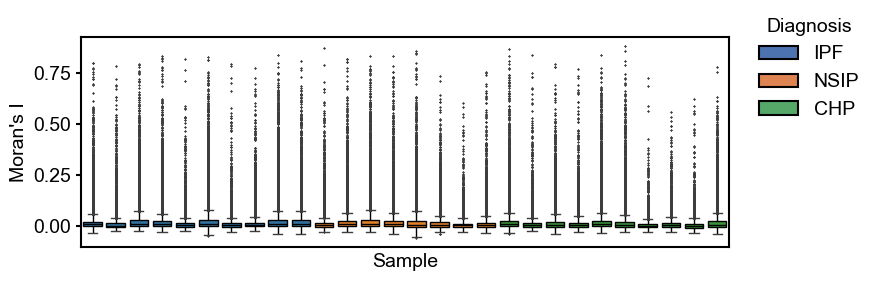

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
labels = ["IPF","NSIP","CHP"]
colors = sns.color_palette("deep", n_colors=3)


# Create the handles (as custom patches) for each outcome_24mition in the legend
import matplotlib.patches as mpatches
# Create the handles (as rectangles) for each outcome_24mition in the legend


fig, ax = plt.subplots(1,1, figsize=(9, 3))
ax = sns.boxplot(
    data=moranI_long_df, x="Library", y="Moran_I", hue="Condition",
    flierprops=flierprops, boxprops=boxprops, whiskerprops=whiskerprops, medianprops=medianprops, legend = False,
    #palette="Set2", dodge=False,
    linewidth=1,  # outline thickness
    #cut=0,        # limits violin to data range
    #inner=None    # disables embedded boxplot
    ax = ax
)
legend_handles = [mpatches.Rectangle((0, 0), 1, 1, facecolor=color, linewidth = 1.5, edgecolor = "black") for color in colors]

plt.legend(legend_handles, labels, title="Diagnosis", loc='center left', bbox_to_anchor=(1.02, 0.85), frameon=False)

plt.title("")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Sample")
plt.ylabel("Moran's I")
ax.set_xticklabels("")
ax.set_xticks([])
plt.tight_layout()
plt.savefig(os.path.join(save_dir,"boxplot_distribution_moranI_by_sample.pdf"), bbox_inches = 'tight', transparent = True)
#lt.legend(title="Condition")
plt.show()


In [16]:
moranI_values

{'IPF': {'18_57617_A1':                 I  pval_norm  var_norm  pval_norm_fdr_bh
  IGKC     0.796651   0.000000  0.000108          0.000000
  SFTPC    0.794968   0.000000  0.000108          0.000000
  SFTPB    0.771100   0.000000  0.000108          0.000000
  COL1A1   0.768235   0.000000  0.000108          0.000000
  SCGB1A1  0.750905   0.000000  0.000108          0.000000
  ...           ...        ...       ...               ...
  SNAPC2  -0.027852   0.004047  0.000108          0.019239
  PET100  -0.028631   0.003235  0.000108          0.015976
  SLC35D2 -0.029277   0.002676  0.000108          0.013606
  ASB7    -0.029408   0.002574  0.000108          0.013165
  SNIP1   -0.032269   0.001062  0.000108          0.006154
  
  [16911 rows x 4 columns],
  '20_33940_B2':                 I  pval_norm  var_norm  pval_norm_fdr_bh
  SFTPC    0.780098   0.000000  0.000081          0.000000
  SCGB3A1  0.719734   0.000000  0.000081          0.000000
  SCGB1A1  0.690943   0.000000  0.000081       

In [17]:
import pandas as pd

# Flatten into a long-form DataFrame
rows = []

for cond, lib_dict in moranI_values.items():
    for lib_id, df in lib_dict.items():
        values = df["pval_norm_fdr_bh"]

        for gene, moran_i in values.items():
            rows.append({
                "Gene": gene,
                "Moran_I": moran_i,
                "Condition": cond,
                "Library": f"{lib_id}"
            })

moranI_pval_long_df = pd.DataFrame(rows)


In [18]:
moranI_pval_long_df

,Gene,Moran_I,Condition,Library
0,IGKC,0.000000,IPF,18_57617_A1
1,SFTPC,0.000000,IPF,18_57617_A1
2,SFTPB,0.000000,IPF,18_57617_A1
3,COL1A1,0.000000,IPF,18_57617_A1
4,SCGB1A1,0.000000,IPF,18_57617_A1
...,...,...,...,...
473118,CDK5,0.019765,CHP,16_39724_B1
473119,ZNF709,0.017419,CHP,16_39724_B1
473120,PAXBP1,0.010555,CHP,16_39724_B1
473121,SNIP1,0.009371,CHP,16_39724_B1


In [19]:
counts = (
    moranI_pval_long_df[(moranI_pval_long_df["Moran_I"] < 0.05)]
    .groupby(["Condition", "Library"])
    .size()
    .reset_index(name="num_significant_genes")
)

In [20]:
counts

,Condition,Library,num_significant_genes
0,CHP,08_38774_B2,858
1,CHP,11_13888_A1,1000
2,CHP,16_39724_B1,3585
3,CHP,17_25789_B1,2551
4,CHP,21_57231_A3,5577
5,CHP,22_18440_A2,2962
6,CHP,23_15209_A3,4193
7,CHP,23_41922_B2,4825
8,CHP,23_50343_B2,2841
9,CHP,24_27523_C5,4363


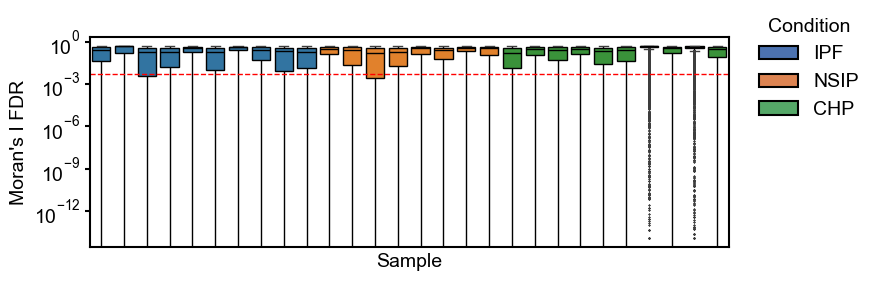

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
labels = ["IPF","NSIP","CHP"]
colors = sns.color_palette("deep", n_colors=3)


# Create the handles (as custom patches) for each outcome_24mition in the legend
import matplotlib.patches as mpatches
# Create the handles (as rectangles) for each outcome_24mition in the legend


fig, ax = plt.subplots(1,1, figsize=(9, 3))
ax = sns.boxplot(
    data=moranI_pval_long_df, x="Library", y="Moran_I", hue="Condition",
    flierprops=flierprops, boxprops=boxprops, whiskerprops=whiskerprops, medianprops=medianprops, legend = False,
    #palette="Set2", dodge=False,
    linewidth=1,  # outline thickness
    #cut=0,        # limits violin to data range
    #inner=None    # disables embedded boxplot
    ax = ax
)
legend_handles = [mpatches.Rectangle((0, 0), 1, 1, facecolor=color, linewidth = 1.5, edgecolor = "black") for color in colors]

plt.legend(legend_handles, labels, title="Condition", loc='center left', bbox_to_anchor=(1.02, 0.85), frameon=False)

plt.title("")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Sample")
plt.ylabel("Moran's I FDR")
ax.set_xticklabels("")
ax.set_xticks([])
ax.set_yscale('log')
ax.axhline(y=0.0055, color='red', linestyle='--', linewidth=1)

plt.tight_layout()

#plt.savefig(os.path.join(save_dir,"boxplot_distribution_moranI_fdr_by_sample.pdf"))
#lt.legend(title="Condition")
plt.show()


In [ ]:
# from scipy.stats import spearmanr
# from statsmodels.stats.multitest import multipletests

# # For each library and for each niche, calculate the spearson correlation between expression of SVGs and niche weight. 
# # Genes in the top 10% by Moran's I of SVGs are kept
# # Spots in the bottom 25% by niche weight are removed


# # Need to calculate correlation between SVGs and "interfaces" (combination of two niches)
# #interface_gene_overlap = {}

# # Also need to calculate correlation between SVGs and niches
# # This will tell me which SVGs are marker genes for distinct niches
# niche_gene_overlap = {}


# library_id_dict = {}

# # For each condition...
# for cond in ['IPF','NSIP','CHP']:
#     # Store library_ids that belong to each condition in a dictionary
#     library_id_dict[cond] = adata_vis.obs[adata_vis.obs['cond'] == cond]["library_id"].unique().tolist()



#     #interface_gene_overlap[cond] = {}
#     niche_gene_overlap[cond] = {}
    
#     # For each library...
#     for library_id in library_id_dict[cond]:
#         # Subset just one library
#         adata_lib = adata_vis[adata_vis.obs['library_id'] == library_id].copy()
#         # Keep row/spot indices for just one library
#         #lib_indices = adata_vis.obs['library_id'] == library_id

#         # Recall moranI_values is a double nested dictionary of the form [cond][library_id]
#         svg_df = moranI_values[cond][library_id]


#         # Drop rows with missing I or p-values
#         svg_df = svg_df.dropna(subset=["I", "pval_norm_fdr_bh"])

#         # Filter based on p-value threshold
#         fdr_threshold = 0.05
#         svg_genes = svg_df[(svg_df["pval_norm_fdr_bh"] < fdr_threshold)].index.tolist()

#         # # Drop NA values (important before percentile calculation)
#         # valid_I = svg_df["I"].dropna()
#         # # Define desired percentile cutoff (e.g., top 10%)
#         # # percentile_cutoff = 75
#         # # cutoff_value = valid_I.quantile(percentile_cutoff / 100)

#         # # Get top genes above the cutoff
#         # svg_genes = valid_I[valid_I >= cutoff_value].index.tolist()
#         # Get the SVGs for just one library
#         # svg_genes = svg_df[svg_df['I'] >= 0.4].index.tolist()  # or use moranI[cond][library_id]

#         # Identify ALL interface columns (e.g., AT1/endo__Fibrotic)
#         #interface_cols = [col for col in adata_vis.obs.columns if '__' in col]
#         #interface_cols = ["AT1/endo__AbBa", "AT1/endo__Fibrotic", "AT2/trans. AT2__AbBa", "Fibrotic__AbBa", "Macro__AbBa"]
#         #interface_cols = ["Fibrotic__Plasma", "Plasma_SMC", "Macro__Fibrotic", "AT2/trans. AT2__B/T immune"]

#         # Identify ALL niche columns (e.g. AT1/endo)
#         niche_cols = adata_vis.obs["factor_assigned"].values.unique()


#         # Create a double nested dictionary (like moranI_values)
#         #interface_gene_overlap[cond][library_id] = {}
#         niche_gene_overlap[cond][library_id] = {}

#         # # For each interface...
#         # for interface in interface_cols:
#         #     # astype(float) to convert catergorical into float for > operation 
#         #     # These are spot-wise
#         #     interface_values = adata_lib.obs.loc[:, interface].astype(float).values
#         #     threshold = np.percentile(interface_values, 25)
#         #     valid_spots_mask = interface_values > threshold 
#         #     filtered_interface_values = interface_values[valid_spots_mask]

#         #     corr_results = []
#         #     # For each gene that are deemed SVGs...
#         #     for gene in svg_genes:
#         #         # First get their index
#         #         gene_idx = adata_lib.var_names.get_loc(gene)
#         #         # Subsetting both genes AND spots with valid_spots_mask
#         #         # This way the lengths of gene_expr and filtered_interface_values are equal to each other
#         #         gene_expr = adata_lib.X[valid_spots_mask,gene_idx].toarray().flatten()

#         #         corr, pval = spearmanr(gene_expr, filtered_interface_values)
#         #         corr_results.append((gene, corr, pval))


#         #     # Sort genes by correlation strength
#         #     corr_df = pd.DataFrame(corr_results, columns=['gene', 'spearman_corr', 'pval'])

#         #     # Adjust p-values using Benjamini–Hochberg (FDR)
#         #     # [0] is a True/False array; Value are stored in [1]
#         #     corr_df['fdr_bh'] = multipletests(corr_df['pval'], method='fdr_bh')[1]
#         #     corr_df = corr_df.sort_values('spearman_corr', ascending=False)

#         #     interface_gene_overlap[cond][library_id][interface] = corr_df

#         # For each niche...
#         for niche in niche_cols:
#             # astype(float) to convert catergorical into float for > operation 
#             niche_values = adata_lib.obs.loc[:, niche].astype(float).values
            
#             threshold = np.percentile(niche_values, 25)
#             valid_spots_mask = niche_values > threshold 


#             filtered_niche_values = niche_values[valid_spots_mask]

#             corr_results = []
#             # For each gene that are deemed SVGs...
#             for gene in svg_genes:


#                 # First get their index
#                 gene_idx = adata_lib.var_names.get_loc(gene)
#                 gene_expr = adata_lib.X[valid_spots_mask,gene_idx].toarray().flatten()

#                 corr, pval = spearmanr(gene_expr, filtered_niche_values)
#                 corr_results.append((gene, corr, pval))


#             # Sort genes by correlation strength
#             corr_df = pd.DataFrame(corr_results, columns=['gene', 'spearman_corr', 'pval'])
#             # Remove any genes with NaN or else fdr_bh fails for all genes...
#             corr_df = corr_df.dropna(subset=["spearman_corr", "pval"])

#             # Adjust p-values using Benjamini–Hochberg (FDR)
#             # [0] is a True/False array; Value are stored in [1]
#             corr_df['fdr_bh'] = multipletests(corr_df['pval'], method='fdr_bh')[1]
#             corr_df = corr_df.sort_values('spearman_corr', ascending=False)

#             niche_gene_overlap[cond][library_id][niche] = corr_df


In [23]:
# np.save("niche_gene_overlap_fdr_cutoff_005_moranI_top75_niche.npy",niche_gene_overlap)

In [24]:
# niche_gene_overlap = np.load("niche_gene_overlap_fdr_cutoff_005_moranI_top75_niche.npy", allow_pickle=True).item()

In [13]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

In [ ]:


# For each library and for each niche, calculate the spearson correlation between expression of SVGs and niche weight. 
# Genes in the top 10% by Moran's I of SVGs are kept
# Spots in the bottom 25% by niche weight are removed


# Need to calculate correlation between SVGs and "interfaces" (combination of two niches)
#interface_gene_overlap = {}

# Also need to calculate correlation between SVGs and niches
# This will tell me which SVGs are marker genes for distinct niches
niche_gene_overlap = {}


library_id_dict = {}

# For each condition...
for cond in ['IPF','NSIP','CHP']:
    # Store library_ids that belong to each condition in a dictionary
    library_id_dict[cond] = adata_vis.obs[adata_vis.obs['cond'] == cond]["library_id"].unique().tolist()



    #interface_gene_overlap[cond] = {}
    niche_gene_overlap[cond] = {}
    
    # For each library...
    for library_id in library_id_dict[cond]:
        # Subset just one library
        adata_lib = adata_vis[adata_vis.obs['library_id'] == library_id].copy()
        # Keep row/spot indices for just one library
        #lib_indices = adata_vis.obs['library_id'] == library_id

        # Recall moranI_values is a double nested dictionary of the form [cond][library_id]
        svg_df = moranI_values[cond][library_id]


        # Drop rows with missing I or p-values
        svg_df = svg_df.dropna(subset=["I", "pval_norm_fdr_bh"])

        # Filter based on p-value threshold
        fdr_threshold = 0.05
        svg_genes = svg_df[(svg_df["pval_norm_fdr_bh"] < fdr_threshold)&(svg_df['I']>0)].index.tolist()

        # # Drop NA values (important before percentile calculation)
        # valid_I = svg_df["I"].dropna()
        # # Define desired percentile cutoff (e.g., top 10%)
        # # percentile_cutoff = 75
        # # cutoff_value = valid_I.quantile(percentile_cutoff / 100)

        # # Get top genes above the cutoff
        # svg_genes = valid_I[valid_I >= cutoff_value].index.tolist()
        # Get the SVGs for just one library
        # svg_genes = svg_df[svg_df['I'] >= 0.4].index.tolist()  # or use moranI[cond][library_id]

        # Identify ALL interface columns (e.g., AT1/endo__Fibrotic)
        #interface_cols = [col for col in adata_vis.obs.columns if '__' in col]
        #interface_cols = ["AT1/endo__AbBa", "AT1/endo__Fibrotic", "AT2/trans. AT2__AbBa", "Fibrotic__AbBa", "Macro__AbBa"]
        #interface_cols = ["Fibrotic__Plasma", "Plasma_SMC", "Macro__Fibrotic", "AT2/trans. AT2__B/T immune"]

        # Identify ALL niche columns (e.g. AT1/endo)
        niche_cols = adata_vis.obs["factor_assigned"].values.unique()


        # Create a double nested dictionary (like moranI_values)
        #interface_gene_overlap[cond][library_id] = {}
        niche_gene_overlap[cond][library_id] = {}

        # # For each interface...
        # for interface in interface_cols:
        #     # astype(float) to convert catergorical into float for > operation 
        #     # These are spot-wise
        #     interface_values = adata_lib.obs.loc[:, interface].astype(float).values
        #     threshold = np.percentile(interface_values, 25)
        #     valid_spots_mask = interface_values > threshold 
        #     filtered_interface_values = interface_values[valid_spots_mask]

        #     corr_results = []
        #     # For each gene that are deemed SVGs...
        #     for gene in svg_genes:
        #         # First get their index
        #         gene_idx = adata_lib.var_names.get_loc(gene)
        #         # Subsetting both genes AND spots with valid_spots_mask
        #         # This way the lengths of gene_expr and filtered_interface_values are equal to each other
        #         gene_expr = adata_lib.X[valid_spots_mask,gene_idx].toarray().flatten()

        #         corr, pval = spearmanr(gene_expr, filtered_interface_values)
        #         corr_results.append((gene, corr, pval))


        #     # Sort genes by correlation strength
        #     corr_df = pd.DataFrame(corr_results, columns=['gene', 'spearman_corr', 'pval'])

        #     # Adjust p-values using Benjamini–Hochberg (FDR)
        #     # [0] is a True/False array; Value are stored in [1]
        #     corr_df['fdr_bh'] = multipletests(corr_df['pval'], method='fdr_bh')[1]
        #     corr_df = corr_df.sort_values('spearman_corr', ascending=False)

        #     interface_gene_overlap[cond][library_id][interface] = corr_df

        # For each niche...
        for niche in niche_cols:
            # astype(float) to convert catergorical into float for > operation 
            niche_values = adata_lib.obs.loc[:, niche].astype(float).values
            
            threshold = np.percentile(niche_values, 25)
            valid_spots_mask = niche_values > threshold 


            filtered_niche_values = niche_values[valid_spots_mask]

            corr_results = []
            # For each gene that are deemed SVGs...
            for gene in svg_genes:


                # First get their index
                gene_idx = adata_lib.var_names.get_loc(gene)
                gene_expr = adata_lib.X[valid_spots_mask,gene_idx].toarray().flatten()

                corr, pval = spearmanr(gene_expr, filtered_niche_values)
                corr_results.append((gene, corr, pval))


            # Sort genes by correlation strength
            corr_df = pd.DataFrame(corr_results, columns=['gene', 'spearman_corr', 'pval'])
            # Remove any genes with NaN or else fdr_bh fails for all genes...
            corr_df = corr_df.dropna(subset=["spearman_corr", "pval"])

            # Adjust p-values using Benjamini–Hochberg (FDR)
            # [0] is a True/False array; Value are stored in [1]
            corr_df['fdr_bh'] = multipletests(corr_df['pval'], method='fdr_bh')[1]
            corr_df = corr_df.sort_values('spearman_corr', ascending=False)

            niche_gene_overlap[cond][library_id][niche] = corr_df


/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/1532182293.py:123: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(gene_expr, filtered_niche_values)
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/1532182293.py:123: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(gene_expr, filtered_niche_values)
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/1532182293.py:123: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(gene_expr, filtered_niche_values)
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/1532182293.py:123: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = spearmanr(gene_expr, filtered_niche_values)
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipy

In [26]:
np.save("niche_gene_overlap_fdr_cutoff_005_I_cutoff_0_moranI_top75_niche.npy",niche_gene_overlap)

In [10]:
niche_gene_overlap = np.load("niche_gene_overlap_fdr_cutoff_005_I_cutoff_0_moranI_top75_niche.npy", allow_pickle=True).item()

In [11]:
niche_gene_overlap

{'IPF': {'18_57617_A1': {'B':        gene  spearman_corr          pval        fdr_bh
   221     LTB       0.562723  7.461382e-42  3.254655e-38
   81   CXCL13       0.548318  2.050815e-39  4.472827e-36
   114   MS4A1       0.512706  7.238383e-34  1.052461e-30
   109     LTF       0.503980  1.323516e-32  1.443295e-29
   414    SPIB       0.503156  1.733836e-32  1.512598e-29
   ..      ...            ...           ...           ...
   331  COL4A1      -0.268090  1.985414e-09  6.984174e-08
   2     SFTPB      -0.286095  1.371927e-10  5.867005e-09
   161  S100A6      -0.305575  6.095648e-12  3.545229e-10
   1     SFTPC      -0.317756  7.701399e-13  5.507132e-11
   14    EPAS1      -0.337923  2.026597e-14  2.156101e-12
   
   [4362 rows x 4 columns],
   'ATI/Endo':        gene  spearman_corr           pval         fdr_bh
   6      AGER       0.772971   0.000000e+00   0.000000e+00
   1     SFTPC       0.682653   0.000000e+00   0.000000e+00
   11   SFTPA1       0.627464  4.604494e-285  6.69646

In [32]:
niche_gene_overlap["IPF"]["20_41615_B1"]["ATI/Endo"]

,gene,spearman_corr,pval,fdr_bh
0,SFTPB,0.835679,0.000000e+00,0.000000e+00
3,SLC34A2,0.809722,0.000000e+00,0.000000e+00
17,KRT7,0.756034,0.000000e+00,0.000000e+00
23,MUC1,0.752490,0.000000e+00,0.000000e+00
14,CEACAM6,0.729203,0.000000e+00,0.000000e+00
...,...,...,...,...
35,PTGDS,-0.445416,8.998335e-111,4.485630e-109
56,IGFBP5,-0.447918,3.804684e-112,1.930792e-110
33,CFD,-0.449431,5.544066e-113,2.865112e-111
6,CCDC80,-0.530021,3.263143e-164,3.169187e-162


In [33]:
niche_gene_overlap["IPF"]["20_41615_B1"]["Airway"]

,gene,spearman_corr,pval,fdr_bh
12,PIGR,0.734723,2.906276e-160,1.637105e-156
28,SLPI,0.675636,2.512105e-126,7.075344e-123
31,WFDC2,0.648450,3.018354e-113,5.667462e-110
5,SCGB3A2,0.628371,2.044861e-104,2.303740e-101
7,SCGB3A1,0.594494,6.630563e-91,4.668745e-88
...,...,...,...,...
186,COL4A2,-0.507111,1.441023e-62,2.536651e-60
63,SPARC,-0.591706,7.290820e-90,4.563243e-87
13,COL1A1,-0.595173,3.684217e-91,2.964742e-88
20,COL1A2,-0.600162,4.711497e-93,4.423311e-90


In [40]:
niche_gene_overlap["IPF"]["20_41615_B1"]["Airway"][(niche_gene_overlap["IPF"]["20_41615_B1"]["Airway"]['fdr_bh'] <0.05) & (niche_gene_overlap["IPF"]["20_41615_B1"]["Airway"]['spearman_corr']  > 0)]

,gene,spearman_corr,pval,fdr_bh
12,PIGR,0.734723,2.906276e-160,1.637105e-156
28,SLPI,0.675636,2.512105e-126,7.075344e-123
31,WFDC2,0.648450,3.018354e-113,5.667462e-110
5,SCGB3A2,0.628371,2.044861e-104,2.303740e-101
7,SCGB3A1,0.594494,6.630563e-91,4.668745e-88
...,...,...,...,...
2919,DGKD,0.069116,3.410864e-02,4.843306e-02
3236,TCEAL3,0.069048,3.428766e-02,4.867500e-02
5035,MEIKIN,0.068963,3.450968e-02,4.897784e-02
5161,PPP1R14B,0.068948,3.454770e-02,4.901944e-02


In [31]:
niche_gene_overlap["IPF"]["20_41615_B1"]["ATI/Endo"][niche_gene_overlap["IPF"]["20_41615_B1"]["ATI/Endo"]['fdr_bh'] <0.05]

,gene,spearman_corr,pval,fdr_bh
0,SFTPB,0.835679,0.000000e+00,0.000000e+00
3,SLC34A2,0.809722,0.000000e+00,0.000000e+00
17,KRT7,0.756034,0.000000e+00,0.000000e+00
23,MUC1,0.752490,0.000000e+00,0.000000e+00
14,CEACAM6,0.729203,0.000000e+00,0.000000e+00
...,...,...,...,...
35,PTGDS,-0.445416,8.998335e-111,4.485630e-109
56,IGFBP5,-0.447918,3.804684e-112,1.930792e-110
33,CFD,-0.449431,5.544066e-113,2.865112e-111
6,CCDC80,-0.530021,3.263143e-164,3.169187e-162


In [66]:
boxprops=dict(edgecolor="black", facecolor = "lightgray")
whiskerprops=dict(color="black")
capprops=dict(color='black')
medianprops=dict(color='r')
flierprops = dict(marker='x', markerfacecolor='lightgrey', markersize=1,
                  linestyle='none')

In [30]:
niche_gene_overlap["IPF"]["20_41615_B1"]["ATI/Endo"][niche_gene_overlap["IPF"]["20_41615_B1"]["ATI/Endo"]['fdr_bh'] > 0.05]

,gene,spearman_corr,pval,fdr_bh
5220,CMBL,0.043693,0.037635,0.050034
4080,C17orf78,0.043623,0.037941,0.050430
4435,GPBAR1,0.043577,0.038144,0.050688
335,LDLRAD1,0.043447,0.038722,0.051444
3347,MPHOSPH8,0.043425,0.038823,0.051566
...,...,...,...,...
2627,DIXDC1,-0.042155,0.044902,0.059277
3478,MSX1,-0.042931,0.041099,0.054435
1547,MYOCD,-0.043077,0.040416,0.053555
5454,VSIR,-0.043112,0.040253,0.053352


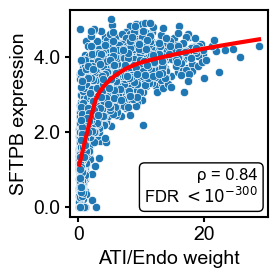

In [35]:
# A representative example of the relationship between SVG expression and niche weight

# Define parameters
gene_name = "SFTPB"
library_id = "20_41615_B1"
niche_name = "ATI/Endo"

# Subset AnnData to the desired library
adata_lib = adata_vis[adata_vis.obs['library_id'] == library_id].copy()

# Get gene index
if gene_name not in adata_lib.var_names:
    raise ValueError(f"Gene {gene_name} not found in the library.")
gene_idx = adata_lib.var_names.get_loc(gene_name)

# Get gene expression values
gene_expr = adata_lib.X[:, gene_idx].toarray().flatten()

# Get niche values and apply thresholding (25th percentile)
niche_values = adata_lib.obs[niche_name].astype(float).values
threshold = np.percentile(niche_values, 25)
valid_mask = niche_values > threshold

# Filter both arrays to the valid spots
gene_expr_filtered = gene_expr[valid_mask]
niche_filtered = niche_values[valid_mask]

# Compute Spearman correlation
corr, pval = spearmanr(gene_expr_filtered, niche_filtered)

# Plot scatter
plt.figure(figsize=(3, 3))
sns.scatterplot(x=niche_filtered, y=gene_expr_filtered)
sns.regplot(x=niche_filtered, y=gene_expr_filtered, scatter=False, color='red', lowess=True)


# Get current axis limits
xlim = plt.xlim()
ylim = plt.ylim()

# Define position for text (e.g., 95% from left, 5% from bottom)
x_text = xlim[0] + 0.95 * (xlim[1] - xlim[0])
y_text = ylim[0] + 0.05 * (ylim[1] - ylim[0])

# Add Spearman's r and p-value
plt.text(
    x_text, y_text,
    f"ρ = {corr:.2f}\nFDR $< 10^{{-300}}$",
    ha='right', va='bottom',
    fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="white")
)


plt.title("")
plt.xlabel(f"{niche_name} weight")
plt.ylabel(f"{gene_name} expression")
import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
plt.tight_layout()
plt.savefig(os.path.join(save_dir,"SFTPB_v_ATI_18_57617_A1.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()


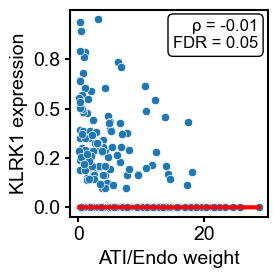

In [14]:
# A representative example of the relationship between SVG expression and niche weight

# Define parameters
gene_name = "KLRK1"
library_id = "20_41615_B1"
niche_name = "ATI/Endo"

# Subset AnnData to the desired library
adata_lib = adata_vis[adata_vis.obs['library_id'] == library_id].copy()

# Get gene index
if gene_name not in adata_lib.var_names:
    raise ValueError(f"Gene {gene_name} not found in the library.")
gene_idx = adata_lib.var_names.get_loc(gene_name)

# Get gene expression values
gene_expr = adata_lib.X[:, gene_idx].toarray().flatten()

# Get niche values and apply thresholding (25th percentile)
niche_values = adata_lib.obs[niche_name].astype(float).values
threshold = np.percentile(niche_values, 25)
valid_mask = niche_values > threshold

# Filter both arrays to the valid spots
gene_expr_filtered = gene_expr[valid_mask]
niche_filtered = niche_values[valid_mask]

# Compute Spearman correlation
corr, pval = spearmanr(gene_expr_filtered, niche_filtered)

# Plot scatter
plt.figure(figsize=(3, 3))
sns.scatterplot(x=niche_filtered, y=gene_expr_filtered)
sns.regplot(x=niche_filtered, y=gene_expr_filtered, scatter=False, color='red', lowess=True)


# Get current axis limits
xlim = plt.xlim()
ylim = plt.ylim()

# Define position for text (e.g., 95% from left, 5% from bottom)
x_text = xlim[0] + 0.95 * (xlim[1] - xlim[0])
y_text = ylim[0] + 0.80 * (ylim[1] - ylim[0])

# Add Spearman's r and p-value
plt.text(
    x_text, y_text,
    f"ρ = {corr:.2f}\nFDR = {0.05}",
    ha='right', va='bottom',
    fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="white")
)


plt.title("")
plt.xlabel(f"{niche_name} weight")
plt.ylabel(f"{gene_name} expression")
import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

plt.tight_layout()
plt.savefig(os.path.join(save_dir,"KLRK1_v_ATI_20_41615_B1.pdf"), bbox_inches = 'tight', transparent = True)

plt.show()


In [187]:
import matplotlib.patches as patches

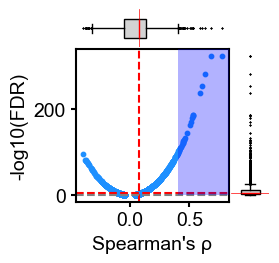

In [212]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
subset = niche_gene_overlap["IPF"]["18_57617_A1"]["ATI/Endo"]
x = subset.loc[subset['fdr_bh'] < 0.05, 'spearman_corr']
y = subset.loc[subset['fdr_bh'] < 0.05, 'fdr_bh']

# Convert to -log10 scale (avoid log(0))
y_transformed = -np.log10(y.replace(0, np.nextafter(0, 1)))
fig = plt.figure(figsize=(2.5,2.5))
gs = gridspec.GridSpec(2, 2, width_ratios=[4,1], height_ratios=[1,4],
                       wspace=0.02, hspace=0.02)

ax_scatter = fig.add_subplot(gs[1,0])
ax_histx   = fig.add_subplot(gs[0,0], sharex=ax_scatter)
ax_histy   = fig.add_subplot(gs[1,1], sharey=ax_scatter)

# scatter
ax_scatter.scatter(x, y_transformed, s=10, color="dodgerblue")
ax_scatter.set_xlabel("Spearman's ρ")
ax_scatter.set_ylabel("-log10(FDR)")
ax_scatter.axhline(y=np.median(y_transformed), color='red', linestyle='--', linewidth=1.5)
ax_scatter.axvline(x=np.median(x), color='red', linestyle='--', linewidth=1.5)
ax_scatter.axhline(y=-np.log10(0.05), color='grey', linestyle='--', linewidth=1.5)

# boxplot of x
ax_histx.boxplot(x, vert=False, patch_artist=True, widths = 0.5,
                 flierprops=flierprops, boxprops=boxprops, whiskerprops=whiskerprops, medianprops=medianprops
                 )
ax_histx.axvline(x=np.median(x), color='red', linestyle='-', linewidth=0.5, zorder=0)
ax_histx.axis("off")

# boxplot of -log10(y)
ax_histy.boxplot(y_transformed, vert=True, patch_artist=True, widths = 0.5,
                 flierprops=flierprops, boxprops=boxprops, whiskerprops=whiskerprops, medianprops=medianprops)
ax_histy.axhline(y=np.median(y_transformed), color='red', linestyle='-', linewidth=0.5, zorder=0)

ax_histy.axis("off")


# Define rectangle limits
x_min = 0.4
y_min = -np.log10(0.05)   # threshold line already drawn
x_max = ax_scatter.get_xlim()[1]  # extend to right edge
y_max = ax_scatter.get_ylim()[1]  # extend to top

# Add rectangle patch
rect = patches.Rectangle(
    (x_min, y_min),
    width = x_max - 0.3,
    height = y_max - y_min,
    linewidth=1.5,

    alpha = 0.3,
    facecolor='blue',
    linestyle="--",
    zorder =4
)
ax_scatter.add_patch(rect)

plt.savefig(os.path.join(save_dir,"spearman_fdr_vs_rho_example.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()


In [195]:
ax_scatter.get_xlim()[1]

0.8928359403564433

In [107]:
sorted(niche_gene_overlap[cond].keys())

['08_38774_B2',
 '11_13888_A1',
 '16_39724_B1',
 '17_25789_B1',
 '21_57231_A3',
 '22_18440_A2',
 '23_15209_A3',
 '23_41922_B2',
 '23_50343_B2',
 '24_27523_C5']

In [26]:
conditions = ["IPF", "NSIP", "CHP"] 
niches_all =['ATI/Endo', 'ATII', 'Adv. FB', 'Airway', 'Alv. FB/immune', 'Alv. macro', 'B', 'Immune', 'Macro', 'Perib. FB', 'Plasma', 'SMC']

In [30]:
# Create new column "lay_id" from "cond_rep", replacing _ with # to look better
adata_vis.obs['lay_id'] = adata_vis.obs['cond_rep'].astype(str).str.replace("_"," #")

In [31]:
# So that we can dynamically switch library_id (key) with lay_id (value)
key_map = dict(zip(adata_vis.obs['library_id'].drop_duplicates(), adata_vis.obs['lay_id'].drop_duplicates()))
key_map

{'18_57617_A1': 'IPF #1',
 '20_33940_B2': 'IPF #2',
 '20_24241_A2': 'IPF #3',
 '19_35057_C3': 'NSIP #1',
 '20_17688_B2': 'NSIP #2',
 '20_28197_A1': 'IPF #4',
 '20_22642_A1': 'NSIP #3',
 '20_41501_C1': 'IPF #5',
 '20_33362_C4': 'NSIP #4',
 '20_41847_A1': 'UNC #1',
 '20_41615_B1': 'IPF #6',
 '21_06301_B2': 'IPF #7',
 '21_05738_A1': 'UNC #2',
 '21_57231_A3': 'CHP #1',
 '21_25528_A3': 'UNC #3',
 '22_18446_A1': 'UNC #4',
 '22_18440_A2': 'CHP #2',
 '23_15209_A3': 'CHP #3',
 '22_50637_A1': 'UNC #5',
 '23_50343_B2': 'CHP #4',
 '23_41922_B2': 'CHP #5',
 '24_10794_B1': 'UNC #7',
 '20_12743_C1': 'UNC #8',
 '21_55244_B1': 'UNC #9',
 '23_45450_A3': 'UNC #10',
 '24_23755_A1': 'UNC #11',
 '16_53837_A10': 'UNC #12',
 '19_48719_A1': 'UNC #13',
 '17_35291_B1': 'UNC #14',
 '16_46257_A1': 'UNC #15',
 '18_23779_A2': 'UNC #16',
 '12_39986_A2': 'UNC #17',
 '20_26330_B3': 'NSIP #5',
 '21_24837_A1': 'NSIP #6',
 '06_30914_A1': 'NSIP #7',
 '19_18542_A4': 'NSIP #8',
 '24_27523_C5': 'CHP #6',
 '11_13888_A1': 'CHP 

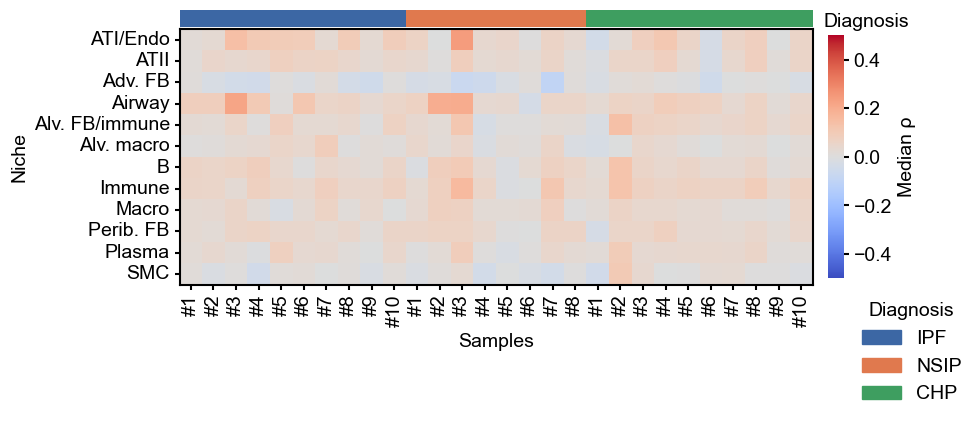

In [73]:
import matplotlib.patches as patches

# Map conditions to colors
cond_colors = {"IPF": "#3c67a4", "NSIP": "#e0794e", "CHP": "#3e9e60"}


# Build the summary DataFrame
summary_df = pd.DataFrame(index=niches_all)

# Collect library_ids sorted by condition
all_library_ids = []
for cond in conditions:
    all_library_ids.extend(sorted(niche_gene_overlap[cond].keys()))
summary_df = pd.DataFrame(index=niches_all, columns=all_library_ids)

# Fill the DataFrame with median Spearman correlations
for cond in conditions:
    for lib_id in sorted(niche_gene_overlap[cond].keys()):
        for niche in niches_all:
            df = niche_gene_overlap[cond][lib_id][niche]
            if df.empty:
                summary_df.loc[niche, lib_id] = np.nan
            else:
                summary_df.loc[niche, lib_id] = df['spearman_corr'].median()

# Convert values to float
summary_df = summary_df.astype(float)
# Determine condition for each library_id
col_colors = []
for lib_id in summary_df.columns:
    for cond in conditions:
        if lib_id in niche_gene_overlap[cond]:
            col_colors.append(cond_colors[cond])


# Create heatmap
fig, ax = plt.subplots(figsize=(10, 4.5))

# Create new df, first sorted by condition then by replicate
df = (summary_df.rename(columns = key_map) # .rename() updates library_id with lay_id
    [
    sorted(
        summary_df.rename(columns=key_map).columns,
        # key= provides the key to sorted()
        # returns a tuple (,)
        # first element is condition order: [].index() returns sorted indices 0, 1, 2 for IPF, NSIP, CHP, respectively
        # second element is numerical replicate order
        key=lambda label: (['IPF','NSIP','CHP'].index(label.split('#')[0].strip()),  # condition
                            int(label.split('#')[1])
                            ) )
] 
)
# Strip everything before # (condition)
df.columns = "#" + df.columns.str.split('#',n = 1, expand = False).str[-1]
sns.heatmap(
    df, 

    cmap="coolwarm",
    center=0,
    annot=False,
    fmt=".0f",
    vmin=-0.5, vmax=0.5,
    cbar_kws={'label': 'Median ρ', 'pad': 0.02, 'shrink': 0.95, 'aspect': 15},
    ax=ax
)
# Add a border by enabling and styling all spines
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color("black")
# Add a color bar rectangle on top of each column
for i, color in enumerate(col_colors):
    rect = patches.Rectangle(
        (i, -0.9),  # (x, y) bottom-left corner; y=-0.5 puts it above first row
        width=1, height=0.8,  # height small to make a thin top bar
        facecolor=color,
        transform=ax.transData,
        
        linewidth=1.5,
        clip_on=False
    )
    ax.add_patch(rect)
ax.text(
    x=len(summary_df.columns) + 0.5,  # slightly right of last column
    y=-0.35,                           # vertical position, aligned with top bar
    s="Diagnosis", 
    fontsize=14, zorder = 2,
    #fontweight="bold",
    va="center"  # vertical alignment
)
# Optionally, add a legend for the conditions
handles = [patches.Patch(color=c, label=k) for k, c in cond_colors.items()]
ax.legend(handles=handles, bbox_to_anchor=(1.05, 0), loc='upper left', title="Diagnosis", frameon = False)

plt.ylabel("Niche")
plt.xlabel("Samples")
plt.tight_layout()
plt.savefig(os.path.join(save_dir,"heatmap_median_rho_niches_vs_samples.pdf"), bbox_inches = 'tight', transparent = True)

plt.show()


In [ ]:
# import matplotlib.patches as patches

# # Map conditions to colors
# cond_colors = {"IPF": "#3c67a4", "NSIP": "#e0794e", "CHP": "#3e9e60"}


# # Build the summary DataFrame
# summary_df = pd.DataFrame(index=niches_all)

# # Collect library_ids sorted by condition
# all_library_ids = []
# for cond in conditions:
#     all_library_ids.extend(sorted(niche_gene_overlap[cond].keys()))
# summary_df = pd.DataFrame(index=niches_all, columns=all_library_ids)

# # Fill the DataFrame with median Spearman correlations
# for cond in conditions:
#     for lib_id in sorted(niche_gene_overlap[cond].keys()):
#         for niche in niches_all:
#             df = niche_gene_overlap[cond][lib_id][niche]
#             if df.empty:
#                 summary_df.loc[niche, lib_id] = np.nan
#             else:
#                 summary_df.loc[niche, lib_id] = df['spearman_corr'].median()

# # Convert values to float
# summary_df = summary_df.astype(float)
# # Determine condition for each library_id
# col_colors = []
# for lib_id in summary_df.columns:
#     for cond in conditions:
#         if lib_id in niche_gene_overlap[cond]:
#             col_colors.append(cond_colors[cond])


# # Create heatmap
# fig, ax = plt.subplots(figsize=(10, 4.5))

# # Create new df, first sorted by condition then by replicate
# df = (summary_df.rename(columns = key_map) # .rename() updates library_id with lay_id
#     [
#     sorted(
#         summary_df.rename(columns=key_map).columns,
#         # key= provides the key to sorted()
#         # returns a tuple (,)
#         # first element is condition order: [].index() returns sorted indices 0, 1, 2 for IPF, NSIP, CHP, respectively
#         # second element is numerical replicate order
#         key=lambda label: (['IPF','NSIP','CHP'].index(label.split('#')[0].strip()),  # condition
#                             int(label.split('#')[1])
#                             ) )
# ] 
# )
# # Strip everything before # (condition)
# df.columns = "#" + df.columns.str.split('#',n = 1, expand = False).str[-1]
# sns.heatmap(
#     summary_df, 

#     cmap="coolwarm",
#     center=0,
#     annot=False,
#     fmt=".0f",
#     vmin=-0.5, vmax=0.5,
#     cbar_kws={'label': 'Median ρ', 'pad': 0.02, 'shrink': 0.95, 'aspect': 15},
#     ax=ax
# )
# # Add a border by enabling and styling all spines
# for spine in ax.spines.values():
#     spine.set_visible(True)
#     spine.set_linewidth(1.5)
#     spine.set_color("black")
# # Add a color bar rectangle on top of each column
# for i, color in enumerate(col_colors):
#     rect = patches.Rectangle(
#         (i, -0.9),  # (x, y) bottom-left corner; y=-0.5 puts it above first row
#         width=1, height=0.8,  # height small to make a thin top bar
#         facecolor=color,
#         transform=ax.transData,
        
#         linewidth=1.5,
#         clip_on=False
#     )
#     ax.add_patch(rect)
# ax.text(
#     x=len(summary_df.columns) + 0.5,  # slightly right of last column
#     y=-0.35,                           # vertical position, aligned with top bar
#     s="Diagnosis", 
#     fontsize=14, zorder = 2,
#     #fontweight="bold",
#     va="center"  # vertical alignment
# )
# # Optionally, add a legend for the conditions
# handles = [patches.Patch(color=c, label=k) for k, c in cond_colors.items()]
# ax.legend(handles=handles, bbox_to_anchor=(1.05, 0), loc='upper left', title="Diagnosis", frameon = False)

# plt.ylabel("Niche")
# plt.xlabel("Samples")
# plt.tight_layout()
# plt.savefig(os.path.join(save_dir,"heatmap_median_rho_niches_vs_samples.pdf"), bbox_inches = 'tight', transparent = True)

# plt.show()



/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwa

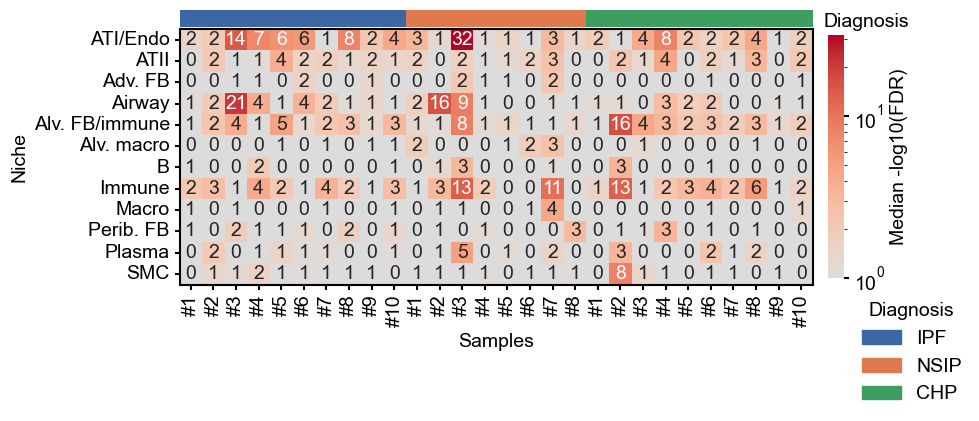

In [74]:
import matplotlib.patches as patches
from matplotlib.colors import LogNorm


# Map conditions to colors
cond_colors = {"IPF": "#3c67a4", "NSIP": "#e0794e", "CHP": "#3e9e60"}


# Build the summary DataFrame
summary_df = pd.DataFrame(index=niches_all)

# Collect library_ids sorted by condition
all_library_ids = []
for cond in conditions:
    all_library_ids.extend(sorted(niche_gene_overlap[cond].keys()))
summary_df = pd.DataFrame(index=niches_all, columns=all_library_ids)

# Fill the DataFrame with median Spearman fdr
for cond in conditions:
    for lib_id in sorted(niche_gene_overlap[cond].keys()):
        for niche in niches_all:
            df = niche_gene_overlap[cond][lib_id][niche]
            if df.empty:
                summary_df.loc[niche, lib_id] = np.nan
            else:
                summary_df.loc[niche, lib_id] = -np.log10(df['fdr_bh']).median()

# Convert values to float
summary_df = summary_df.astype(float)
# Determine condition for each library_id
col_colors = []
for lib_id in summary_df.columns:
    for cond in conditions:
        if lib_id in niche_gene_overlap[cond]:
            col_colors.append(cond_colors[cond])


# Create heatmap
fig, ax = plt.subplots(figsize=(10, 4.5))
# Create new df, first sorted by condition then by replicate
df = (summary_df.rename(columns = key_map) # .rename() updates library_id with lay_id
    [
    sorted(
        summary_df.rename(columns=key_map).columns,
        # key= provides the key to sorted()
        # returns a tuple (,)
        # first element is condition order: [].index() returns sorted indices 0, 1, 2 for IPF, NSIP, CHP, respectively
        # second element is numerical replicate order
        key=lambda label: (['IPF','NSIP','CHP'].index(label.split('#')[0].strip()),  # condition
                            int(label.split('#')[1])
                            ) )
] 
)
# Strip everything before # (condition)
df.columns = "#" + df.columns.str.split('#',n = 1, expand = False).str[-1]
sns.heatmap(
    df,

    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".0f",
    norm=LogNorm(vmin=1, vmax=summary_df.max().max()),  
    #vmin=-0.5, vmax=0.5,
    cbar_kws={'label': 'Median -log10(FDR)', 'pad': 0.02, 'shrink': 0.95, 'aspect': 15},
    ax=ax
)

# Add a border by enabling and styling all spines
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color("black")
# Add a color bar rectangle on top of each column
for i, color in enumerate(col_colors):
    rect = patches.Rectangle(
        (i, -0.9),  # (x, y) bottom-left corner; y=-0.5 puts it above first row
        width=1, height=0.8,  # height small to make a thin top bar
        facecolor=color,
        transform=ax.transData,
        
        linewidth=1.5,
        clip_on=False
    )
    ax.add_patch(rect)
ax.text(
    x=len(summary_df.columns) + 0.5,  # slightly right of last column
    y=-0.35,                           # vertical position, aligned with top bar
    s="Diagnosis", 
    fontsize=14, zorder = 2,
    #fontweight="bold",
    va="center"  # vertical alignment
)
# Optionally, add a legend for the conditions
handles = [patches.Patch(color=c, label=k) for k, c in cond_colors.items()]
ax.legend(handles=handles, bbox_to_anchor=(1.05, 0), loc='upper left', title="Diagnosis", frameon = False)

plt.ylabel("Niche")
plt.xlabel("Samples")
plt.tight_layout()
plt.savefig(os.path.join(save_dir,"heatmap_median_fdr_niches_vs_samples.pdf"), bbox_inches = 'tight', transparent = True)

plt.show()


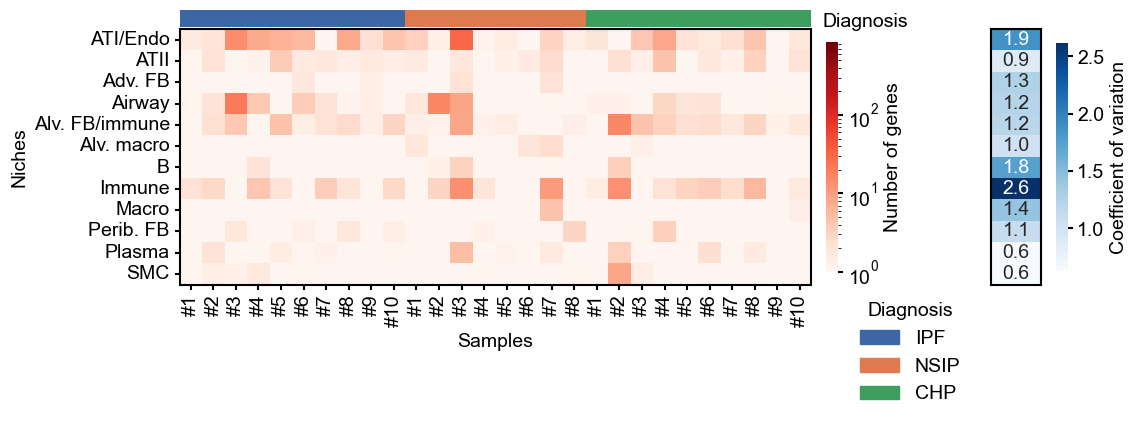

In [76]:
from matplotlib.colors import LogNorm

# Map conditions to colors
cond_colors = {"IPF": "#3c67a4", "NSIP": "#e0794e", "CHP": "#3e9e60"}

# Build the summary DataFrame: number of genes with spearman_corr > 0.5 and fdr_bh < 0.05
summary_df_count = pd.DataFrame(index=niches_all, columns=[lib_id for cond in conditions for lib_id in sorted(niche_gene_overlap[cond].keys())])

for cond in conditions:
    for lib_id in sorted(niche_gene_overlap[cond].keys()):
        for niche in niches_all:
            df = niche_gene_overlap[cond][lib_id][niche]
            if df.empty:
                summary_df_count.loc[niche, lib_id] = 0
            else:
                # Count genes meeting criteria
                count = ((df['spearman_corr'] >= 0.4) & (df['fdr_bh'] < 0.05)).sum()
                summary_df_count.loc[niche, lib_id] = count

summary_df_count = summary_df_count.astype(int)

row_cv = summary_df_count.std(axis=1) / summary_df_count.mean(axis=1)
# Determine condition for each library_id
col_colors = []
for lib_id in summary_df_count.columns:
    for cond in conditions:
        if lib_id in niche_gene_overlap[cond]:
            col_colors.append(cond_colors[cond])

# Create heatmap
fig,ax = plt.subplots(1,2,figsize=(11.6, 4.5),
                      gridspec_kw={'width_ratios': [10, 1]})
# Create new df, first sorted by condition then by replicate
df = (summary_df.rename(columns = key_map) # .rename() updates library_id with lay_id
    [
    sorted(
        summary_df.rename(columns=key_map).columns,
        # key= provides the key to sorted()
        # returns a tuple (,)
        # first element is condition order: [].index() returns sorted indices 0, 1, 2 for IPF, NSIP, CHP, respectively
        # second element is numerical replicate order
        key=lambda label: (['IPF','NSIP','CHP'].index(label.split('#')[0].strip()),  # condition
                            int(label.split('#')[1])
                            ) )
] 
)
# Strip everything before # (condition)
df.columns = "#" + df.columns.str.split('#',n = 1, expand = False).str[-1]
sns.heatmap(
    df,

    cmap="Reds",
    #annot=True,
    norm=LogNorm(vmin=1, vmax=summary_df_count.max().max()),  
    fmt="d",
    cbar_kws={'label': 'Number of genes', 'pad': 0.02, 'shrink': 0.9},
    ax=ax[0]
)
ax[0].set_xlabel("Samples")
ax[0].set_ylabel("Niches")

# Side heatmap for row-wise standard deviation
#ax[1]= fig.add_subplot(gs[1])
sns.heatmap(
    pd.DataFrame(row_cv),  # convert series to DataFrame
    cmap="Blues",
    cbar_kws={'label': 'Coefficient of variation', 'pad':0.2},
    ax=ax[1],
    annot=True,
    fmt=".1f"
)
# Hide axis labels and ticks
ax[1].set_xlabel("")
ax[1].set_ylabel("")
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_yticklabels([])

# Add a border by enabling and styling all spines
for spine in ax[0].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color("black")
for spine in ax[1].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color("black")

# Add top color bar rectangle for condition
for i, color in enumerate(col_colors):
    rect = patches.Rectangle(
        (i, -0.9),
        width=1, height=0.8,
        facecolor=color,
        transform=ax[0].transData,
        linewidth=1.5,
        clip_on=False
    )
    ax[0].add_patch(rect)

# Add "Diagnosis" label
ax[0].text(
    x=len(summary_df_count.columns) + 0.5,
    y=-0.35,
    s="Diagnosis",
    fontsize=14, zorder=2,
    va="center"
)



# Add legend for conditions
handles = [patches.Patch(color=c, label=k) for k, c in cond_colors.items()]
ax[0].legend(handles=handles, bbox_to_anchor=(1.05, 0), loc='upper left', title="Diagnosis", frameon=False)

# plt.ylabel("Niche")
# plt.xlabel("Samples")
plt.tight_layout()
plt.savefig(os.path.join(save_dir,"heatmap_count_rho04_fdr005.pdf"), bbox_inches='tight', transparent=True)
plt.show()


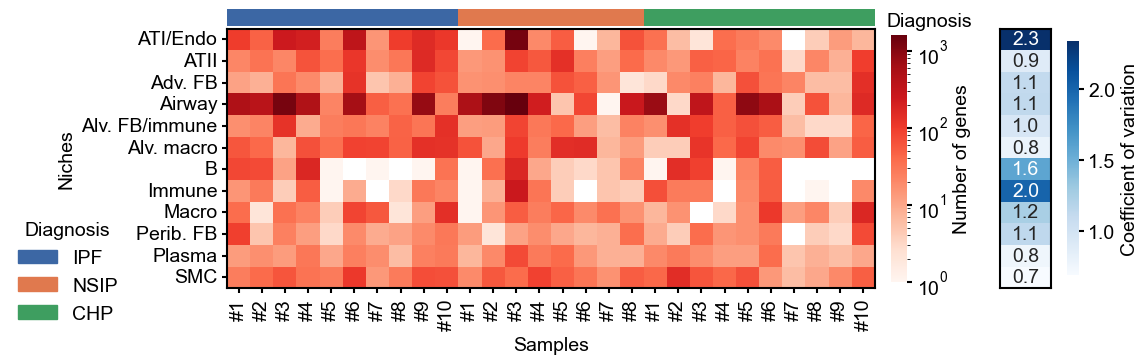

In [116]:
from matplotlib.colors import LogNorm

# Map conditions to colors
cond_colors = {"IPF": "#3c67a4", "NSIP": "#e0794e", "CHP": "#3e9e60"}

# Build the summary DataFrame: number of genes with spearman_corr > 0.5 and fdr_bh < 0.05
summary_df_count = pd.DataFrame(index=niches_all, columns=[lib_id for cond in conditions for lib_id in sorted(niche_gene_overlap[cond].keys())])

for cond in conditions:
    for lib_id in sorted(niche_gene_overlap[cond].keys()):
        for niche in niches_all:
            df = niche_gene_overlap[cond][lib_id][niche]
            if df.empty:
                summary_df_count.loc[niche, lib_id] = 0
            else:
                # Count genes meeting criteria
                count = ((df['spearman_corr'] >= 0.3) & (df['fdr_bh'] < 0.05)).sum()
                summary_df_count.loc[niche, lib_id] = count

summary_df_count = summary_df_count.astype(int)

row_cv = summary_df_count.std(axis=1) / summary_df_count.mean(axis=1)
# Determine condition for each library_id
col_colors = []
for lib_id in summary_df_count.columns:
    for cond in conditions:
        if lib_id in niche_gene_overlap[cond]:
            col_colors.append(cond_colors[cond])

# Create heatmap
fig,ax = plt.subplots(1,2,figsize=(11.6, 3.9),
                      gridspec_kw={'width_ratios': [10, 1]})
# Create new df, first sorted by condition then by replicate
df = (summary_df_count.rename(columns = key_map) # .rename() updates library_id with lay_id
    [
    sorted(
        summary_df_count.rename(columns=key_map).columns,
        # key= provides the key to sorted()
        # returns a tuple (,)
        # first element is condition order: [].index() returns sorted indices 0, 1, 2 for IPF, NSIP, CHP, respectively
        # second element is numerical replicate order
        key=lambda label: (['IPF','NSIP','CHP'].index(label.split('#')[0].strip()),  # condition
                            int(label.split('#')[1])
                            ) )
] 
)
# Strip everything before # (condition)
df.columns = "#" + df.columns.str.split('#',n = 1, expand = False).str[-1]
sns.heatmap(
    df,
    cmap="Reds",
    #annot=True,
    norm=LogNorm(vmin=1, vmax=summary_df_count.max().max()),  
    fmt="d",
    cbar_kws={'label': 'Number of genes', 'pad': 0.02, 'shrink': 0.95, 'aspect': 15},
    ax=ax[0]
)
ax[0].set_xlabel("Samples")
ax[0].set_ylabel("Niches")

# Side heatmap for row-wise standard deviation
#ax[1]= fig.add_subplot(gs[1])
sns.heatmap(
    pd.DataFrame(row_cv),  # convert series to DataFrame
    cmap="Blues",
    cbar_kws={'label': 'Coefficient of variation', 'pad':0.2},
    ax=ax[1],
    annot=True,
    fmt=".1f"
)
# Hide axis labels and ticks
ax[1].set_xlabel("")
ax[1].set_ylabel("")
ax[1].set_xticks([])
ax[1].set_yticks([])
ax[1].set_yticklabels([])

# Add a border by enabling and styling all spines
for spine in ax[0].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color("black")
for spine in ax[1].spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color("black")

# Add top color bar rectangle for condition
for i, color in enumerate(col_colors):
    rect = patches.Rectangle(
        (i, -0.9),
        width=1, height=0.8,
        facecolor=color,
        transform=ax[0].transData,
        linewidth=1.5,
        clip_on=False
    )
    ax[0].add_patch(rect)

# Add "Diagnosis" label
ax[0].text(
    x=len(summary_df_count.columns) + 0.5,
    y=-0.35,
    s="Diagnosis",
    fontsize=14, zorder=2,
    va="center"
)



# Add legend for conditions
handles = [patches.Patch(color=c, label=k) for k, c in cond_colors.items()]
ax[0].legend(handles=handles, bbox_to_anchor=(-0.35, -0.2), loc='lower left', title="Diagnosis", frameon=False)

# plt.ylabel("Niche")
# plt.xlabel("Samples")
plt.tight_layout()
plt.savefig(os.path.join(save_dir,"heatmap_count_rho03_fdr005.pdf"), bbox_inches='tight', transparent=True)
plt.show()


In [268]:
summary_df_genes = pd.DataFrame(index=niches_all, columns=all_library_ids, dtype=object)
for cond in conditions:
    for lib_id in sorted(niche_gene_overlap[cond].keys()):
        for niche in niches_all:
            df = niche_gene_overlap[cond][lib_id][niche]
            if df.empty:
                summary_df_genes.loc[niche, lib_id] = []
            else:
                mask = (df['spearman_corr'] >= 0.4) & (df['fdr_bh'] < 0.05)
                genes = df.loc[mask, 'gene'].tolist()
                summary_df_genes.loc[niche, lib_id] = genes



In [269]:
summary_df_genes

,18_57617_A1,20_24241_A2,20_28197_A1,20_33940_B2,20_41501_C1,20_41615_B1,21_06301_B2,21_24095_A3,21_55747_C3,22_16220_B1,06_30914_A1,19_18542_A4,19_35057_C3,20_17688_B2,20_22642_A1,20_26330_B3,20_33362_C4,21_24837_A1,08_38774_B2,11_13888_A1,16_39724_B1,17_25789_B1,21_57231_A3,22_18440_A2,23_15209_A3,23_41922_B2,23_50343_B2,24_27523_C5
ATI/Endo,"[AGER, SFTPC, SFTPA1, NHERF2, EPAS1, CAV1, GPR...","[SFTPB, SLC34A2, AGER, AQP4, S100A6, GPRC5A, K...","[SFTPB, SFTPC, SLC34A2, SFTPA1, NAPSA, SFTPD, ...","[SFTPC, SFTPB, SFTPA1, AGER, SERPINA1, SLC22A3...","[SFTPC, AGER, SFTPA1, SFTPB]","[SFTPB, SLC34A2, KRT7, MUC1, CEACAM6, NAPSA, G...","[SFTPB, SFTPC, SFTPA1, SLC34A2]","[SFTPB, SFTPC, SLC34A2, NAPSA, GPRC5A, AGER, K...","[AGER, GPRC5A, KRT7, CLIC5, EMP2, SFTPB, SLC34...","[EPAS1, CAV1, EMP2, FCN3, SLC6A4, GPRC5A, AGER...",[SFTPB],"[SFTPB, KRT7, SLC34A2, AGER, CEACAM6, MUC1, GP...",[],"[AGER, TMSB4X, SERPINA1, COL4A1, ZFP36, FOS, F...","[SFTPB, SLC34A2, NAPSA, MUC1, SFTPD, KRT7, SFT...","[EPAS1, FCN3, CAV1, AGER, EMP2, LMO7, KRT7, CL...","[SERPINA1, KRT7, SFTPB, SFTPC, MUC1, SLC34A2, ...",[],"[SFTPB, SFTPC, SLC34A2, SFTPA1, TMSB4X]",[],[],[],"[SFTPB, SFTPC, AGER, SFTPA1, SFTPD, NAPSA, SLC...","[AGER, SFTPC, SFTPB]",[],"[AGER, EPAS1, CAV1, FCN3, SLC6A4]","[AGER, EPAS1, SFTPB]","[AGER, EPAS1, SFTPC, SLC34A2, SFTPB, CAV1]"
ATII,"[SFTPB, SLC34A2, SFTPD, NAPSA, MUC1, CTSH, SLC...","[SFTPA1, SFTPC, SFTPD, LRRK2, NAPSA, SERPINA1,...","[SFTPC, SFTPD, SFTPB, NAPSA, SLC34A2, SFTPA1, ...","[SFTPC, SFTPB, SFTPA1, SFTPD, LPCAT1, SLC22A31...","[SFTPC, SFTPA1, SFTPB, SFTPD, LRRK2, NAPSA, SL...","[SFTPC, NAPSA, SFTPB, NPC2, SFTPD, SFTPA1, SLC...","[SFTPB, SFTPC, SFTPA1, SLC34A2]","[SFTPC, SFTPB, SLC34A2, NAPSA, SFTPA1, LRRK2, ...","[NAPSA, SFTPC, SLC34A2, SFTPB, CTSH, SFTPA1, S...","[NAPSA, SFTPC, SLC34A2, SFTPB, CTSH, SFTPA1, L...","[SFTPB, SFTPC, SFTPA1, SLC34A2, SFTPD, NAPSA]","[SFTPB, SLC34A2, SFTPC, NAPSA, CTSH, SFTPD, FA...","[SFTPC, SFTPB, SLC34A2, SFTPA1, NAPSA, CTSH, N...","[SFTPC, SFTPA1, SFTPB, SFTPD, NAPSA, SLC34A2, ...","[NAPSA, SFTPD, SFTPA1, SFTPB, NPC2, SLC34A2, C...","[SFTPB, SLC34A2, NAPSA, SFTPC, MUC1, LRRK2, SF...","[SFTPB, SLC34A2, SFTPC, SFTPA1, SFTPD, NAPSA, ...","[SFTPC, SFTPB, SLC34A2, SFTPA1, NAPSA, NPC2, L...","[SFTPB, SFTPC, SLC34A2, SFTPA1]",[SFTPC],"[SFTPB, NAPSA, SLC34A2, SFTPC, CTSH, LRRK2, MU...","[SFTPC, SFTPB, SLC34A2, MUC1, SFTPA1, NAPSA, S...","[SFTPB, SFTPC, SFTPA1, SLC34A2, NAPSA, SFTPD, ...","[SFTPB, SFTPC, SLC34A2, SFTPD, NAPSA, NPC2]","[SFTPB, SFTPC, SLC34A2, CTSH, SFTPD, MUC1, NAP...","[SFTPC, SFTPB, SFTPA1, SFTPD, NAPSA, SLC34A2, ...","[SFTPB, SFTPC, SFTPA1, SFTPD, NAPSA, SLC34A2, ...","[SFTPB, NAPSA, SFTPD, SLC34A2, SFTPC, CTSH, SE..."
Adv. FB,[CCDC80],"[MGP, CCDC80, DCN, C3, SFRP2, FBLN1, SFRP1, C1...","[FBLN1, MGP, DCN, CCDC80, C7, C3, C1R, SFRP2]",[SFRP2],"[MGP, DCN, C3, C7, A2M]","[CCDC80, C3, FBLN1, DCN, MGP, C7, C1R, SFRP1, ...",[DCN],"[CCDC80, MGP, DCN]","[C3, DCN, CCDC80, FBLN1, CFD, C1R, MGP, SFRP1,...","[CCDC80, FBLN1, C3, MGP, DCN, CLU, C1R, C7, SE...","[CCDC80, DCN, MGP, C3, CFD, C7, SCARA5]",[],"[DCN, CCDC80, C3, FBLN1, C7, MGP, SFRP2, PTGDS...","[MGP, FBLN1, DCN, SFRP2, CCDC80, C3, C7]","[DCN, CCDC80, FBLN1, C3, MGP, SFRP2, C1R, CFD,...","[CCDC80, C7, CFD, FBLN1, DCN, MGP, SCARA5, IGF...","[IGFBP4, MGP, CLU, DCN, PTGDS, CCDC80]","[CCDC80, SFRP2, DCN, C1R, FBLN1, SFRP4, SERPIN...",[DCN],"[DCN, CCDC80, CFD, C3, FBLN1, TNXB, C1R, SFRP4...","[FBLN1, DCN, CCDC80, C3, SCARA5, SERPINF1, C1R...","[C7, CCDC80]",[],"[C7, MGP, FBLN1, DCN, IGFBP4, SFRP2, C3, CCDC80]","[C7, CCDC80, MGP, SFRP1, PI16, FBLN1, DCN]","[FBLN1, C7, C3, MGP, C1R, IGFBP7, PTGIS, CCDC8...",[CCDC80],"[CCDC80, DCN, C3, FBLN1, MGP, C7, CFD, PI16, T..."
Airway,"[SCGB1A1, PIGR, SCGB3A1, C9orf24, CAPS, C20orf...","[PIGR, WFDC2, CAPS, EZR, MS4A8, C9orf24, C20or...","[PIGR, WFDC2, SLPI, SCGB3A2, MAPK15, SCGB3A1, ...","[PIGR, SCGB3A1, WFDC2, SLPI, SCGB1A1, C20orf85...","[SCGB3A1, BPIFB1, WFDC2, SLPI, PIGR, MUC5B, BP...","[PIGR, SLPI, WFDC2,

In [ ]:


# Map library → condition
lib_to_cond = {}
for cond in conditions:
    for lib_id in niche_gene_overlap[cond].keys():
        lib_to_cond[lib_id] = cond

In [275]:
lib_to_cond

{'18_57617_A1': 'IPF',
 '20_33940_B2': 'IPF',
 '20_24241_A2': 'IPF',
 '20_28197_A1': 'IPF',
 '20_41501_C1': 'IPF',
 '20_41615_B1': 'IPF',
 '21_06301_B2': 'IPF',
 '21_24095_A3': 'IPF',
 '21_55747_C3': 'IPF',
 '22_16220_B1': 'IPF',
 '19_35057_C3': 'NSIP',
 '20_17688_B2': 'NSIP',
 '20_22642_A1': 'NSIP',
 '20_33362_C4': 'NSIP',
 '20_26330_B3': 'NSIP',
 '21_24837_A1': 'NSIP',
 '06_30914_A1': 'NSIP',
 '19_18542_A4': 'NSIP',
 '21_57231_A3': 'CHP',
 '22_18440_A2': 'CHP',
 '23_15209_A3': 'CHP',
 '23_50343_B2': 'CHP',
 '23_41922_B2': 'CHP',
 '24_27523_C5': 'CHP',
 '11_13888_A1': 'CHP',
 '17_25789_B1': 'CHP',
 '08_38774_B2': 'CHP',
 '16_39724_B1': 'CHP'}

In [301]:
threshold_frac = 0.3

# Prepare empty DataFrame: rows = niches, columns = conditions
summary_df_common = pd.DataFrame(index=niches_all, columns=conditions, dtype=object)

for niche in niches_all:
    for cond in conditions:
        # Collect all gene lists for this niche and condition
        gene_lists = [
            set(niche_gene_overlap[cond][lib_id][niche].loc[
                (niche_gene_overlap[cond][lib_id][niche]['spearman_corr'] >= 0.4) &
                (niche_gene_overlap[cond][lib_id][niche]['fdr_bh'] < 0.05), 'gene'
            ])
            for lib_id in niche_gene_overlap[cond].keys()
            if not niche_gene_overlap[cond][lib_id][niche].empty
        ]
        
        if not gene_lists:
            summary_df_common.loc[niche, cond] = set()
            continue
        
        # Count occurrence of each gene
        from collections import Counter
        gene_counts = Counter()
        for gset in gene_lists:
            gene_counts.update(gset)
        
        num_libs = len(gene_lists)
        # Keep genes that appear in >= threshold fraction of libraries
        common_genes = {gene for gene, count in gene_counts.items() if count / num_libs >= threshold_frac}
        
        summary_df_common.loc[niche, cond] = common_genes

In [334]:
summary_df_common.iloc[:, ::-1]

,CHP,NSIP,IPF
ATI/Endo,"{AGER, SFTPB, CAV1, EPAS1, SFTPC, SLC34A2}","{SERPINA1, GPRC5A, KRT7, AGER, CEACAM6, SFTPB,...","{SERPINA1, MLPH, EMP2, KRT7, CTSH, CTSE, SCEL,..."
ATII,"{SFTPA1, MLPH, SFTPD, LAMP3, CTSH, SLC22A31, F...","{SERPINA1, DMBT1, MLPH, CTSH, NAPSA, SLPI, SFT...","{SERPINA1, DMBT1, ACOXL, MLPH, DRAM1, CTSH, NA..."
Adv. FB,"{C1R, DCN, CFD, SFRP2, MGP, FBLN1, PI16, C7, C...","{C1R, DCN, CFD, SFRP2, MGP, FBLN1, PTGDS, C7, ...","{DCN, SFRP1, CFD, PTGIS, C7, C1S, C3, CCDC80, ..."
Airway,"{C6orf118, KLK10, ODF3B, DYNC2H1, CCL15, CCDC1...","{C6orf118, KLK10, ODF3B, DYNC2H1, CCDC170, CEP...","{C6orf118, MUC20, KLK10, ODF3B, DYNC2H1, CCDC1..."
Alv. FB/immune,"{COL6A1, COL14A1, MMP2, DCN, COL6A3, IGHA1, CF...","{DCN, PTGDS, A2M}","{COL14A1, SELENOP, MMP2, DCN, LUM, IGHA1, MFAP..."
Alv. macro,"{SERPINA1, TYROBP, MCEMP1, FTH1, C1QA, FBP1, A...","{SERPINA1, MCEMP1, FTH1, C1QA, GCHFR, FBP1, AP...","{SERPINA1, TYROBP, MCEMP1, FTH1, VIM, C1QA, GC..."
B,"{CXCR4, MS4A1, BLK, TNFRSF13C}",{MS4A1},"{LTB, NIBAN3, SPIB, CD37, CXCR4}"
Immune,"{CXCR4, TRAC}",{},"{TRAC, CORO1A}"
Macro,"{GPNMB, FTL, FTH1, MMP9, LYZ, CHIT1, APOE, CTS...","{FTL, CTSD, APOE, CTSZ, CTSB, CCL18, PSAP}","{GPNMB, FTL, CD74, LGALS3, CTSB, FTH1, CAPG, C..."
Perib. FB,"{COL5A2, MMP2, SPARC, COL6A3, COMP, COL1A1, CO...","{MMP2, SPARC, COL6A3, COL1A1, COL5A1, COL1A2, ...","{COL5A2, MMP2, COL6A3, SPARC, COL1A2, CTHRC1, ..."


/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles[

<Figure size 300x300 with 0 Axes>

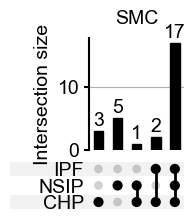

In [342]:
from upsetplot import from_contents, UpSet
import matplotlib.pyplot as plt

smc_common_dict = summary_df_common.iloc[:, ::-1].loc["SMC"].to_dict()
# keys = conditions, values = sets of common genes
upset_data = from_contents(smc_common_dict)
plt.figure(figsize=(3,3))
upset = UpSet(upset_data, show_counts='%d', sort_by='degree', totals_plot_elements=0, sort_categories_by=None, element_size = 18)
upset.plot()
plt.title("SMC", fontsize = 14, pad = 10)
plt.savefig(os.path.join(save_dir,"SMC_condition_wise_upset_thr03_rho04_fdr005.pdf"), bbox_inches = 'tight', transparent=True)
plt.show()


In [346]:
# Loop over all niches
for niche in summary_df_common.index:
    niche_dict = summary_df_common.iloc[:, ::-1].loc[niche].to_dict()
    upset_data = from_contents(niche_dict)
    
    # Explicit figure
    fig = plt.figure()
    
    # Pass figure to UpSet
    upset = UpSet(
        upset_data,
        show_counts='%d',
        sort_by='degree',
        totals_plot_elements=0,
        sort_categories_by=None,
        element_size = 24
    )
    upset.plot(fig=fig)  # pass figure here
    
    # Title
    plt.title(niche, fontsize=14, pad=10)
    
    # Sanitize filename
    safe_niche = re.sub(r'[^A-Za-z0-9_\-]', '_', niche)
    filename = f"{safe_niche}_condition_wise_upset_thr03_rho04_fdr005.pdf"
    
    # Save
    fig.savefig(os.path.join(save_dir, filename), bbox_inches='tight', transparent=True)
    plt.close(fig)


/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles[

In [570]:
threshold_frac = 0.3

# Prepare empty DataFrame: rows = niches, columns = conditions
summary_df_common = pd.DataFrame(index=niches_all, columns=conditions, dtype=object)

for niche in niches_all:
    for cond in conditions:
        # Collect all gene lists for this niche and condition
        gene_lists = [
            set(niche_gene_overlap[cond][lib_id][niche].loc[
                (niche_gene_overlap[cond][lib_id][niche]['spearman_corr'] >= 0.4) &
                (niche_gene_overlap[cond][lib_id][niche]['fdr_bh'] < 0.05), 'gene'
            ])
            for lib_id in niche_gene_overlap[cond].keys()
            if not niche_gene_overlap[cond][lib_id][niche].empty
        ]
        
        if not gene_lists:
            summary_df_common.loc[niche, cond] = set()
            continue
        
        # Count occurrence of each gene
        from collections import Counter
        gene_counts = Counter()
        for gset in gene_lists:
            gene_counts.update(gset)
        
        num_libs = len(gene_lists)
        # Keep genes that appear in >= threshold fraction of libraries
        common_genes = {gene for gene, count in gene_counts.items() if count / num_libs >= threshold_frac}
        
        summary_df_common.loc[niche, cond] = common_genes

In [571]:
summary_df_common

,IPF,NSIP,CHP
ATI/Endo,"{SERPINA1, MLPH, EMP2, KRT7, CTSH, CTSE, SCEL,...","{SERPINA1, GPRC5A, KRT7, AGER, CEACAM6, SFTPB,...","{AGER, SFTPB, CAV1, EPAS1, SFTPC, SLC34A2}"
ATII,"{SERPINA1, DMBT1, ACOXL, MLPH, DRAM1, CTSH, NA...","{SERPINA1, DMBT1, MLPH, CTSH, NAPSA, SLPI, SFT...","{SFTPA1, MLPH, SFTPD, LAMP3, CTSH, SLC22A31, F..."
Adv. FB,"{DCN, SFRP1, CFD, PTGIS, C7, C1S, C3, CCDC80, ...","{C1R, DCN, CFD, SFRP2, MGP, FBLN1, PTGDS, C7, ...","{C1R, DCN, CFD, SFRP2, MGP, FBLN1, PI16, C7, C..."
Airway,"{C6orf118, MUC20, KLK10, ODF3B, DYNC2H1, CCDC1...","{C6orf118, KLK10, ODF3B, DYNC2H1, CCDC170, CEP...","{C6orf118, KLK10, ODF3B, DYNC2H1, CCL15, CCDC1..."
Alv. FB/immune,"{COL14A1, SELENOP, MMP2, DCN, LUM, IGHA1, MFAP...","{DCN, PTGDS, A2M}","{COL6A1, COL14A1, MMP2, DCN, COL6A3, IGHA1, CF..."
Alv. macro,"{SERPINA1, TYROBP, MCEMP1, FTH1, VIM, C1QA, GC...","{SERPINA1, MCEMP1, FTH1, C1QA, GCHFR, FBP1, AP...","{SERPINA1, TYROBP, MCEMP1, FTH1, C1QA, FBP1, A..."
B,"{LTB, NIBAN3, SPIB, CD37, CXCR4}",{MS4A1},"{CXCR4, MS4A1, BLK, TNFRSF13C}"
Immune,"{TRAC, CORO1A}",{},"{CXCR4, TRAC}"
Macro,"{GPNMB, FTL, CD74, LGALS3, CTSB, FTH1, CAPG, C...","{FTL, CTSD, APOE, CTSZ, CTSB, CCL18, PSAP}","{GPNMB, FTL, FTH1, MMP9, LYZ, CHIT1, APOE, CTS..."
Perib. FB,"{COL5A2, MMP2, COL6A3, SPARC, COL1A2, CTHRC1, ...","{MMP2, SPARC, COL6A3, COL1A1, COL5A1, COL1A2, ...","{COL5A2, MMP2, SPARC, COL6A3, COMP, COL1A1, CO..."


/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/Users/jk/miniconda3/envs/scvi-tools/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles[

<Figure size 640x480 with 0 Axes>

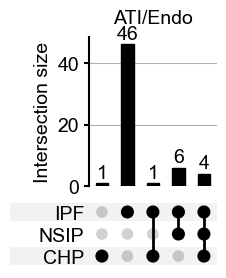

<Figure size 640x480 with 0 Axes>

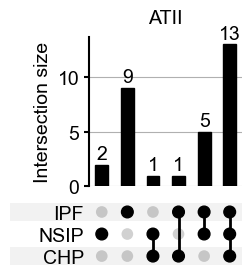

<Figure size 640x480 with 0 Axes>

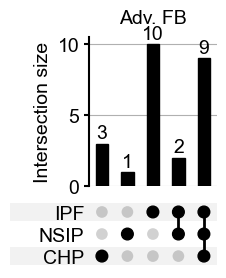

<Figure size 640x480 with 0 Axes>

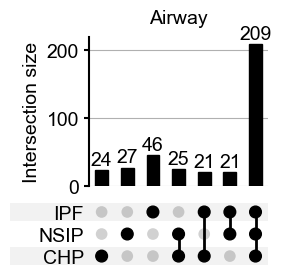

<Figure size 640x480 with 0 Axes>

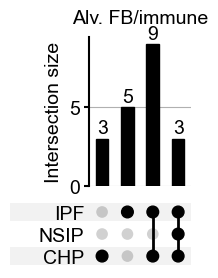

<Figure size 640x480 with 0 Axes>

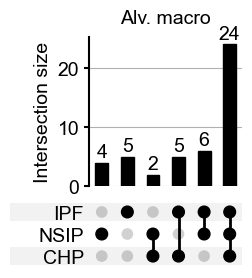

<Figure size 640x480 with 0 Axes>

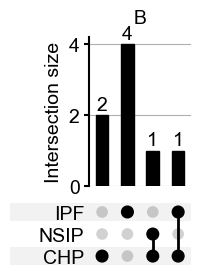

<Figure size 640x480 with 0 Axes>

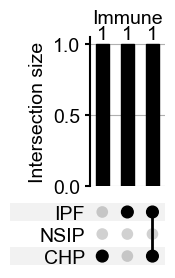

<Figure size 640x480 with 0 Axes>

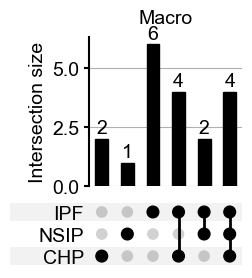

<Figure size 640x480 with 0 Axes>

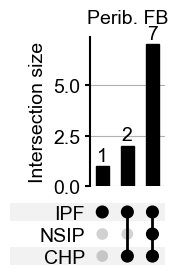

<Figure size 640x480 with 0 Axes>

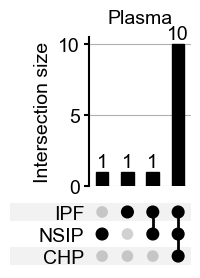

<Figure size 640x480 with 0 Axes>

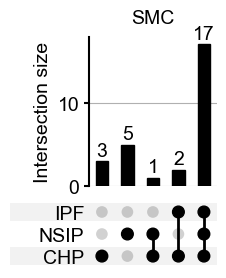

In [574]:
# Loop over all niches
for niche in summary_df_common.index:
    niche_dict = summary_df_common.iloc[:, ::-1].loc[niche].to_dict()
    upset_data = from_contents(niche_dict)
    # Skip if all lists are empty
    if all(len(genes) == 0 for genes in niche_dict.values()):
        print(f"Skipping {niche}, no genes found.")
        continue
    # Explicit figure
    fig = plt.figure()
    
    # Pass figure to UpSet
    upset = UpSet(
        upset_data,
        show_counts='%d',
        sort_by='degree',
        totals_plot_elements=0,
        sort_categories_by=None,
        element_size = 24
    )
    upset.plot()  # pass figure here
    
    # Title
    plt.title(niche, fontsize=14, pad=10)
    import re
    
    # Sanitize filename
    safe_niche = re.sub(r'[^A-Za-z0-9_\-]', '_', niche)
    filename = f"{safe_niche}_condition_wise_upset_thr03_rho04_fdr005.pdf"
    
    # Save
    plt.savefig(os.path.join(save_dir, filename), bbox_inches='tight', transparent=True)
    #plt.close(fig)


In [575]:
niche_dict = summary_df_common.iloc[:, ::-1].loc['ATI/Endo'].to_dict()
niche_dict

{'CHP': {'AGER', 'CAV1', 'EPAS1', 'SFTPB', 'SFTPC', 'SLC34A2'},
 'NSIP': {'AGER',
  'CEACAM6',
  'GPRC5A',
  'KRT7',
  'MUC1',
  'NAPSA',
  'SERPINA1',
  'SFTPB',
  'SFTPC',
  'SLC34A2'},
 'IPF': {'AGER',
  'ANXA2',
  'ANXA3',
  'AQP3',
  'AQP4',
  'ATP13A4',
  'C1orf116',
  'CADM1',
  'CAV1',
  'CAV2',
  'CCND1',
  'CD55',
  'CD9',
  'CEACAM6',
  'CLIC5',
  'CPM',
  'CTSE',
  'CTSH',
  'CYB5A',
  'DHCR24',
  'EMP2',
  'EZR',
  'FBP1',
  'FCN3',
  'FOLR1',
  'FXYD3',
  'GPRC5A',
  'HOPX',
  'KRT7',
  'KRT8',
  'LAMP3',
  'LMO3',
  'LMO7',
  'LPCAT1',
  'MLPH',
  'MUC1',
  'MYH14',
  'NAPSA',
  'NDNF',
  'NKX2-1',
  'NPC2',
  'PRX',
  'RAB11FIP1',
  'S100A6',
  'SCEL',
  'SDC4',
  'SERPINA1',
  'SFTA3',
  'SFTPA1',
  'SFTPB',
  'SFTPC',
  'SFTPD',
  'SLC22A31',
  'SLC34A2',
  'SLPI',
  'TMSB4X',
  'WIF1'}}

In [576]:
niche_dict = summary_df_common.iloc[:, ::-1].loc['Perib. FB'].to_dict()
niche_dict

{'CHP': {'COL1A1',
  'COL1A2',
  'COL3A1',
  'COL5A1',
  'COL5A2',
  'COL6A3',
  'COMP',
  'MMP2',
  'SPARC'},
 'NSIP': {'COL1A1', 'COL1A2', 'COL3A1', 'COL5A1', 'COL6A3', 'MMP2', 'SPARC'},
 'IPF': {'COL1A1',
  'COL1A2',
  'COL3A1',
  'COL5A1',
  'COL5A2',
  'COL6A3',
  'COMP',
  'CTHRC1',
  'MMP2',
  'SPARC'}}

In [401]:
set.intersection(*summary_df_common.iloc[:, ::-1].loc[niche].to_dict().values())

{'ACTA2',
 'ACTG2',
 'CALD1',
 'CNN1',
 'CSRP1',
 'DES',
 'FLNA',
 'IGFBP7',
 'LMOD1',
 'MYH11',
 'MYL9',
 'MYLK',
 'SPEG',
 'SYNPO2',
 'TAGLN',
 'TPM1',
 'TPM2'}

In [406]:
all_results = []
for niche in ["ATII","Adv. FB","Airway","Alv. macro","Perib. FB","Plasma","SMC"]:
    genes = set.intersection(*summary_df_common.iloc[:, ::-1].loc[niche].to_dict().values())



    enr = gp.enrichr(
        gene_list=list(genes),
        gene_sets='GO_Biological_Process_2021',
        organism='Human',
        outdir='enrichr_results',
        cutoff=1.0
    )
    df = enr.results.copy()
    df["niche"] = niche
    all_results.append(df)

# Combine all results
combined = pd.concat(all_results, ignore_index=True)
combined["Adjusted P-value"] = pd.to_numeric(combined["Adjusted P-value"], errors='coerce')
combined.dropna(subset=["Adjusted P-value"], inplace=True)
combined["-log10(padj)"] = -np.log10(combined["Adjusted P-value"].replace(0, 1e-300))

In [407]:
combined

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,niche,-log10(padj)
0,GO_Biological_Process_2021,cellular protein metabolic process (GO:0044267),7/417,2.508972e-09,7.546090e-07,0,0,55.706911,1103.185824,SFTPB;SLC34A2;NAPSA;SFTPC;SFTPD;CTSH;SFTPA1,ATII,6.122278
1,GO_Biological_Process_2021,surfactant homeostasis (GO:0043129),3/7,7.496116e-09,7.546090e-07,0,0,1498.725000,28039.467442,NAPSA;SFTPD;CTSH,ATII,6.122278
2,GO_Biological_Process_2021,chemical homeostasis within a tissue (GO:0048875),3/7,7.496116e-09,7.546090e-07,0,0,1498.725000,28039.467442,NAPSA;SFTPD;CTSH,ATII,6.122278
3,GO_Biological_Process_2021,membrane protein proteolysis (GO:0033619),2/39,2.851004e-04,2.152508e-02,0,0,98.034398,800.222350,NAPSA;CTSH,ATII,1.667055
4,GO_Biological_Process_2021,pattern recognition receptor signaling pathway...,2/61,6.984425e-04,3.989901e-02,0,0,61.411402,446.255637,SFTPD;SFTPA1,ATII,1.399038
...,...,...,...,...,...,...,...,...,...,...,...,...
2168,GO_Biological_Process_2021,regulation of apoptotic process (GO:0042981),1/742,4.742650e-01,4.855571e-01,0,0,1.622976,1.210722,FLNA,SMC,0.313760
2169,GO_Biological_Process_2021,"negative regulation of transcription, DNA-temp...",1/948,5.621418e-01,5.721206e-01,0,0,1.256336,0.723651,FLNA,SMC,0.242512
2170,GO_Biological_Process_2021,cellular protein modification process (GO:0006...,1/1025,5.912840e-01,5.982403e-01,0,0,1.157166,0.608043,IGFBP7,SMC,0.223124
2171,GO_Biological_Process_2021,"positive regulation of transcription, DNA-temp...",1/1183,6.454628e-01,6.492374e-01,0,0,0.994131,0.435218,ACTA2,SMC,0.187596


In [408]:
# Remove text within parentheses (and the parentheses themselves)
combined['Term'] = combined['Term'].str.replace(r'\s*\(.*?\)', '', regex=True)
combined

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,niche,-log10(padj)
0,GO_Biological_Process_2021,cellular protein metabolic process,7/417,2.508972e-09,7.546090e-07,0,0,55.706911,1103.185824,SFTPB;SLC34A2;NAPSA;SFTPC;SFTPD;CTSH;SFTPA1,ATII,6.122278
1,GO_Biological_Process_2021,surfactant homeostasis,3/7,7.496116e-09,7.546090e-07,0,0,1498.725000,28039.467442,NAPSA;SFTPD;CTSH,ATII,6.122278
2,GO_Biological_Process_2021,chemical homeostasis within a tissue,3/7,7.496116e-09,7.546090e-07,0,0,1498.725000,28039.467442,NAPSA;SFTPD;CTSH,ATII,6.122278
3,GO_Biological_Process_2021,membrane protein proteolysis,2/39,2.851004e-04,2.152508e-02,0,0,98.034398,800.222350,NAPSA;CTSH,ATII,1.667055
4,GO_Biological_Process_2021,pattern recognition receptor signaling pathway,2/61,6.984425e-04,3.989901e-02,0,0,61.411402,446.255637,SFTPD;SFTPA1,ATII,1.399038
...,...,...,...,...,...,...,...,...,...,...,...,...
2168,GO_Biological_Process_2021,regulation of apoptotic process,1/742,4.742650e-01,4.855571e-01,0,0,1.622976,1.210722,FLNA,SMC,0.313760
2169,GO_Biological_Process_2021,"negative regulation of transcription, DNA-temp...",1/948,5.621418e-01,5.721206e-01,0,0,1.256336,0.723651,FLNA,SMC,0.242512
2170,GO_Biological_Process_2021,cellular protein modification process,1/1025,5.912840e-01,5.982403e-01,0,0,1.157166,0.608043,IGFBP7,SMC,0.223124
2171,GO_Biological_Process_2021,"positive regulation of transcription, DNA-temp...",1/1183,6.454628e-01,6.492374e-01,0,0,0.994131,0.435218,ACTA2,SMC,0.187596


In [418]:
top_terms = []

for niche in ["ATII","Adv. FB","Airway","Alv. macro","Perib. FB","Plasma","SMC"]:
    niche_data = combined[combined["niche"] == niche]
    top5 = (
        niche_data.groupby("Term")["Adjusted P-value"]
        .min()
        .sort_values()
        .head(5)
        .index
    )
    top_terms.extend(top5)

# Unique union of top terms across niches
unique_terms = list(pd.Series(top_terms).unique())

# Filter combined results for those terms
filtered = combined[combined["Term"].isin(unique_terms)].copy()

# Create a combined column for heatmap columns


In [419]:
# Pivot to term × (niche_condition)
heatmap_data = filtered.pivot_table(
    index="Term",
    columns="niche",
    values="-log10(padj)",
    fill_value=0
)

import scipy.cluster.hierarchy as sch
# Optional: sort rows by average signal
#heatmap_data = heatmap_data.loc[heatmap_data.mean(axis=1).sort_values(ascending=False).index]
# Perform hierarchical clustering on columns (niche_condition)
# We are clustering columns based on their similarity
Z = sch.linkage(heatmap_data, method='complete', metric='euclidean')

# Get the order of columns based on hierarchical clustering
dendrogram = sch.dendrogram(Z, no_plot=True)
row_order = dendrogram['leaves']


#desired_condition_order = ['IPF', 'NSIP', 'CHP']

# Extract unique niches
# niches = sorted({label.split('_')[0] for label in heatmap_data.columns})

# Build ordered column list like macro_IPF, macro_NSIP, macro_CHP, ...
#col_order = [f"{niche}_{cond}" for niche in niches for cond in desired_condition_order if f"{niche}_{cond}" in heatmap_data.columns]



# Reorder the rows of the heatmap
heatmap_data = heatmap_data.iloc[row_order,:]
# Reorder the columns of the heatmap 
#heatmap_data = heatmap_data.loc[:,col_order]

In [435]:
heatmap_data.T

Term,cilium movement,cilium organization,determination of left/right symmetry,axonemal dynein complex assembly,cilium assembly,muscle contraction,extracellular matrix organization,external encapsulating structure organization,extracellular structure organization,collagen fibril organization,skin development,neutrophil degranulation,neutrophil activation involved in immune response,neutrophil mediated immunity,cell junction disassembly,"complement activation, classical pathway",cellular protein metabolic process,chemical homeostasis within a tissue,surfactant homeostasis,regulation of complement activation,regulation of humoral immune response,regulation of immune effector process,"complement activation, alternative pathway",negative regulation of locomotion,smooth muscle contraction,regulation of muscle contraction,actin-myosin filament sliding,platelet aggregation,membrane protein proteolysis,regulation of cellular catabolic process,regulation of immunoglobulin production,positive regulation of immunoglobulin production,positive regulation of production of molecular mediator of immune response,negative regulation of programmed cell death,positive regulation of interleukin-6 production
niche,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ATII,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.360950,1.360950,1.360950,0.000000,0.000000,6.122278,6.122278,6.122278,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.667055,1.399038,0.000000,0.000000,0.000000,0.634427,0.000000
Adv. FB,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.848655,0.953774,0.953774,0.00000,0.000000,1.370043,1.370043,1.370043,0.000000,1.528465,0.731864,0.000000,0.000000,4.042706,4.042706,4.042706,3.779573,1.528465,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Airway,43.188295,12.280048,11.851599,18.895037,20.337826,0.000000,0.000000,0.000000,0.000000,0.00000,0.119508,0.119508,0.117162,0.116249,0.000000,0.000000,0.001212,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.131215,0.000000,0.000000,0.000000,0.001212,0.000000
Alv. macro,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,10.792003,10.792003,10.792003,5.342631,4.963436,1.292955,0.000000,0.000000,2.852313,2.843561,2.843561,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.420919,0.932727
Perib. FB,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.292558,12.112958,12.112958,9.10836,6.801357,0.000000,0.000000,0.000000,0.000000,0.000000,0.844319,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Plasma,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.635574,0.635574,0.635574,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.111887,2.111887,2.111887,1.656502,1.656502
SMC,0.000000,0.703631,0.000000,0.000000,0.590304,15.551227,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.497854,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.799324,4.024353,3.916867,3.916867,0.000000,0.000000,0.000000,0.000000,0.000000,0.528394,0.000000


/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/1140637947.py:44: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


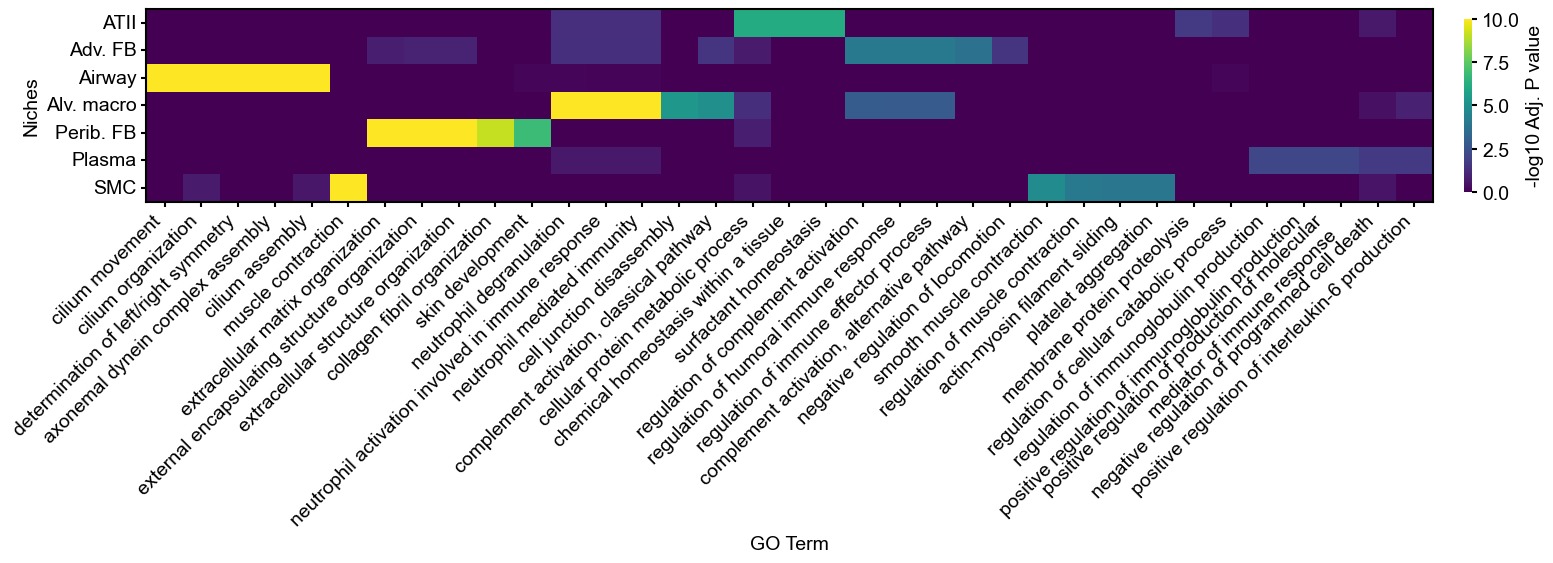

In [476]:
import seaborn as sns
import matplotlib.pyplot as plt

import textwrap

# wrap GO term names (x tick labels) before plotting
wrapped_labels = [textwrap.fill(label, width=50) for label in heatmap_data.T.columns]

# color_dict = dict(zip(
# ['ATI/Endo',
#  'Perib. FB',
#  'ATII',
#  'Plasma',
#  'Airway',
#  'B',
#  'Alv. macro',
#  'Alv. FB/immune',
#  'Adv. FB',
#  'Macro',
#  'Immune',
#  'SMC'],
#  ['#ff7f00', '#33a02c', '#fdbf6f', '#1f78b4', '#fb9a99', '#cab2d6', '#6a3d9a', '#ffff99', '#b15928', '#b2df8a', '#a6cee3', '#e31a1c']

# ))



fig, ax = plt.subplots(figsize=(20,2.5))
sns.heatmap(heatmap_data.T, cmap="viridis", annot=False, fmt=".1f",  vmax = 10, ax = ax,
                
    cbar_kws={'label': '-log10 Adj. P value', 'pad': 0.02, 'shrink': 0.9})
plt.title("")
# Add a border by enabling and styling all spines
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color("black")
ax.tick_params(axis="y", labelsize=14)
plt.ylabel("Niches")
plt.xlabel("GO Term")
plt.xticks(rotation=45, ha="right")
# Apply wrapped labels to x-axis
ax.set_xticklabels(wrapped_labels, rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(save_dir,"hm_gsea_common_upset.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()


In [415]:
heatmap_data

niche,ATII,Adv. FB,Airway,Alv. macro,Perib. FB,Plasma,SMC
Term,,,,,,,
muscle contraction,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.551227
external encapsulating structure organization,0.000000,0.953774,0.000000,0.000000,12.112958,0.000000,0.000000
extracellular structure organization,0.000000,0.953774,0.000000,0.000000,12.112958,0.000000,0.000000
neutrophil activation involved in immune response,1.360950,1.370043,0.117162,10.792003,0.000000,0.635574,0.000000
neutrophil degranulation,1.360950,1.370043,0.119508,10.792003,0.000000,0.635574,0.000000
cellular protein metabolic process,6.122278,0.731864,0.001212,1.292955,0.844319,0.000000,0.497854
chemical homeostasis within a tissue,6.122278,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
regulation of complement activation,0.000000,4.042706,0.000000,2.852313,0.000000,0.000000,0.000000
regulation of humoral immune response,0.000000,4.042706,0.000000,2.843561,0.000000,0.000000,0.000000


In [460]:
for niche in ['ATI/Endo']:
    niche_dict = summary_df_common.iloc[:, ::-1].loc[niche].to_dict()
    unique_per_cond = {}
    for cond, genes in niche_dict.items():
        # subtract all other sets from this one
        others = set.union(*(niche_dict[c] for c in niche_dict if c != cond))
        unique_per_cond[cond] = genes - others

In [462]:
unique_per_cond['IPF']

{'ANXA2',
 'ANXA3',
 'AQP3',
 'AQP4',
 'ATP13A4',
 'C1orf116',
 'CADM1',
 'CAV2',
 'CCND1',
 'CD55',
 'CD9',
 'CLIC5',
 'CPM',
 'CTSE',
 'CTSH',
 'CYB5A',
 'DHCR24',
 'EMP2',
 'EZR',
 'FBP1',
 'FCN3',
 'FOLR1',
 'FXYD3',
 'HOPX',
 'KRT8',
 'LAMP3',
 'LMO3',
 'LMO7',
 'LPCAT1',
 'MLPH',
 'MYH14',
 'NDNF',
 'NKX2-1',
 'NPC2',
 'PRX',
 'RAB11FIP1',
 'S100A6',
 'SCEL',
 'SDC4',
 'SFTA3',
 'SFTPA1',
 'SFTPD',
 'SLC22A31',
 'SLPI',
 'TMSB4X',
 'WIF1'}

In [468]:
genes = unique_per_cond["IPF"]


enr = gp.enrichr(
gene_list=list(genes),
gene_sets='GO_Biological_Process_2021',
organism='Human',
outdir='enrichr_results',
cutoff=0.05
)
df = enr.results.copy()


# Combine all results
combined = df
combined["Adjusted P-value"] = pd.to_numeric(combined["Adjusted P-value"], errors='coerce')
combined.dropna(subset=["Adjusted P-value"], inplace=True)
combined["-log10(padj)"] = -np.log10(combined["Adjusted P-value"].replace(0, 1e-300))

In [469]:
combined

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,-log10(padj)
0,GO_Biological_Process_2021,T cell mediated immunity (GO:0002456),4/16,4.366670e-08,0.000028,0,0,158.269841,2682.148372,CADM1;CTSH;EMP2;CD55,4.553670
1,GO_Biological_Process_2021,T cell mediated cytotoxicity (GO:0001913),3/8,6.324694e-07,0.000202,0,0,278.358140,3973.182208,CADM1;CTSH;EMP2,3.693811
2,GO_Biological_Process_2021,caveola assembly (GO:0070836),2/5,5.152282e-05,0.006738,0,0,302.287879,2984.635086,CAV2;EMP2,2.171451
3,GO_Biological_Process_2021,epithelial tube branching involved in lung mor...,2/6,7.717120e-05,0.006738,0,0,226.704545,2146.775129,NKX2-1;CTSH,2.171451
4,GO_Biological_Process_2021,membrane raft assembly (GO:0001765),2/6,7.717120e-05,0.006738,0,0,226.704545,2146.775129,ANXA2;EMP2,2.171451
...,...,...,...,...,...,...,...,...,...,...,...
635,GO_Biological_Process_2021,positive regulation of intracellular signal tr...,1/546,7.204884e-01,0.724546,0,0,0.791397,0.259440,CAV2,0.139934
636,GO_Biological_Process_2021,negative regulation of cellular macromolecule ...,1/547,7.211493e-01,0.724546,0,0,0.789906,0.258228,NKX2-1,0.139934
637,GO_Biological_Process_2021,"positive regulation of transcription, DNA-temp...",2/1183,7.647842e-01,0.767182,0,0,0.722539,0.193757,NKX2-1;LMO7,0.115102
638,GO_Biological_Process_2021,cellular protein modification process (GO:0006...,1/1025,9.113307e-01,0.912757,0,0,0.410807,0.038143,LMO7,0.039645


In [488]:
combined.to_excel("SVGs_unique_to_IPF_ATI_Endo_gseapy.xlsx")

In [522]:
from matplotlib.patches import Rectangle

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/3490312003.py:17: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/3490312003.py:34: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/3490312003.py:34: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/3490312003.py:34: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/3490312003.py:34: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


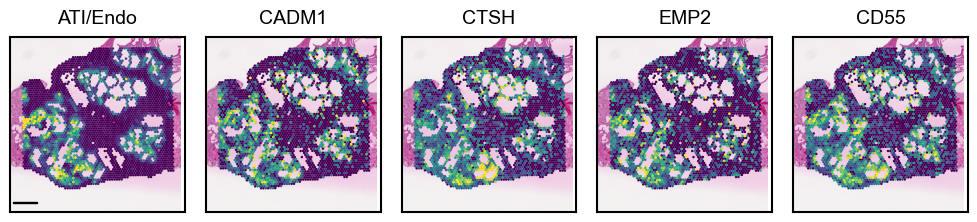

In [ ]:
fig, ax = plt.subplots(1,5, figsize=(2*5, 2.3))
# Add scalebar
scale_bar_length = adata_vis.uns['spatial']["20_41615_B1"]['scalefactors']['tissue_hires_scalef'] # Length of the scale bar in whatever units 
                # with ax1.transAxes, this is the proportion of the total pixel width
                # ex. 10th of 14000 px, where each px is 0.5 micron
scale_bar_height = 0.01 # Height of the scale bar (adjust as needed)

# Create a rectangle for the scale bar on top of the plot
scale_bar = Rectangle(
(0.02,0.05),  # Bottom-left corner of the rectangle (relative coordinates)
width=scale_bar_length,  # Length of the scale bar
height=scale_bar_height,  # Height of the scale bar
transform=ax[0].transAxes,  # Transform relative to the axis
color='black',  # Color of the scale bar
linewidth=1  # Thickness of the scale bar
)
sc.pl.spatial(
    adata_vis[adata_vis.obs['library_id']=="20_41615_B1"],        
    library_id = "20_41615_B1",
    color="ATI/Endo",
    size=1.5,
    vmax = 'p99',
    ax=ax[0],
    show=False,
    colorbar_loc = None
    #title=gene
)
ax[0].set_title("ATI/Endo", fontsize = 14, pad =10)
ax[0].set_xlabel("")
ax[0].set_ylabel("")
ax[0].set_xlim(0,2000)
ax[0].set_ylim(2000,0)
for i, gene in enumerate(['CADM1','CTSH',"EMP2","CD55"]):
    sc.pl.spatial(
        adata_vis[adata_vis.obs['library_id']=="20_41615_B1"],       
        library_id = "20_41615_B1",
        color=gene,
        size=1.5,
        vmax = 'p99',
        ax=ax[i+1],
        show=False,
        colorbar_loc = None
        #title=gene
    )
    ax[i+1].set_title(gene, fontsize = 14, pad =10)
    ax[i+1].set_xlabel("")
    ax[i+1].set_ylabel("")
    ax[i+1].set_xlim(0,2000)
    ax[i+1].set_ylim(2000,0)
ax[0].add_patch(scale_bar)

plt.tight_layout()
plt.savefig(os.path.join(save_dir,"IPF_20_41615_B1_ATI_Endo_four_unique_svgs.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/1470204878.py:17: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/1470204878.py:34: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/1470204878.py:34: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/1470204878.py:34: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/1470204878.py:34: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


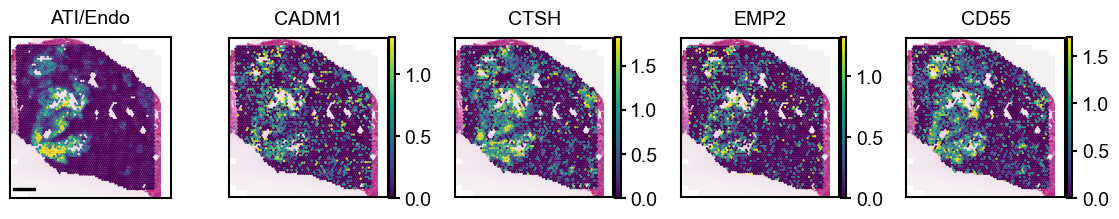

In [ ]:
fig, ax = plt.subplots(1,5, figsize=(2.3*5, 2.3))
# Add scalebar
scale_bar_length = adata_vis.uns['spatial']["20_28197_A1"]['scalefactors']['tissue_hires_scalef'] # Length of the scale bar in whatever units
                # with ax1.transAxes, this is the proportion of the total pixel width
                # ex. 10th of 14000 px, where each px is 0.5 micron
scale_bar_height = 0.01 # Height of the scale bar (adjust as needed)

# Create a rectangle for the scale bar on top of the plot
scale_bar = Rectangle(
(0.02,0.05),  # Bottom-left corner of the rectangle (relative coordinates)
width=scale_bar_length,  # Length of the scale bar
height=scale_bar_height,  # Height of the scale bar
transform=ax[0].transAxes,  # Transform relative to the axis
color='black',  # Color of the scale bar
linewidth=1  # Thickness of the scale bar
)
sc.pl.spatial(
    adata_vis[adata_vis.obs['library_id']=="20_28197_A1"],       
    library_id = "20_28197_A1",
    color="ATI/Endo",
    size=1.5,
    vmax = 'p99',
    ax=ax[0],
    show=False,
    colorbar_loc = None
    #title=gene
)
ax[0].set_title("ATI/Endo", fontsize = 14, pad =10)
ax[0].set_xlabel("")
ax[0].set_ylabel("")
ax[0].set_xlim(0,2000)
ax[0].set_ylim(2000,0)
for i, gene in enumerate(['CADM1','CTSH',"EMP2","CD55"]):
    sc.pl.spatial(
        adata_vis[adata_vis.obs['library_id']=="20_28197_A1"],      
        library_id = "20_28197_A1",
        color=gene,
        size=1.5,
        vmax = 'p99',
        ax=ax[i+1],
        show=False,
        #colorbar_loc = None
        #title=gene
    )
    ax[i+1].set_title(gene, fontsize = 14, pad =10)
    ax[i+1].set_xlabel("")
    ax[i+1].set_ylabel("")
    ax[i+1].set_xlim(0,2000)
    ax[i+1].set_ylim(2000,0)
ax[0].add_patch(scale_bar)

plt.tight_layout()
plt.savefig(os.path.join(save_dir,"IPF_20_28197_A1_ATI_Endo_four_unique_svgs.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/1694500371.py:17: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/1694500371.py:34: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/1694500371.py:34: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/1694500371.py:34: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/1694500371.py:34: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


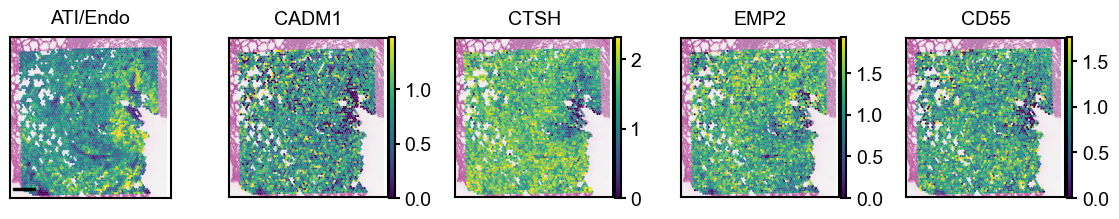

In [ ]:
fig, ax = plt.subplots(1,5, figsize=(2.3*5, 2.3))
# Add scalebar
scale_bar_length = adata_vis.uns['spatial']["21_24837_A1"]['scalefactors']['tissue_hires_scalef'] # Length of the scale bar in whatever units
                # with ax1.transAxes, this is the proportion of the total pixel width
                # ex. 10th of 14000 px, where each px is 0.5 micron
scale_bar_height = 0.01 # Height of the scale bar (adjust as needed)

# Create a rectangle for the scale bar on top of the plot
scale_bar = Rectangle(
(0.02,0.05),  # Bottom-left corner of the rectangle (relative coordinates)
width=scale_bar_length,  # Length of the scale bar
height=scale_bar_height,  # Height of the scale bar
transform=ax[0].transAxes,  # Transform relative to the axis
color='black',  # Color of the scale bar
linewidth=1  # Thickness of the scale bar
)
sc.pl.spatial(
    adata_vis[adata_vis.obs['library_id']=="21_24837_A1"],      
    library_id = "21_24837_A1",
    color="ATI/Endo",
    size=1.5,
    vmax = 'p99',
    ax=ax[0],
    show=False,
    colorbar_loc = None
    #title=gene
)
ax[0].set_title("ATI/Endo", fontsize = 14, pad =10)
ax[0].set_xlabel("")
ax[0].set_ylabel("")
ax[0].set_xlim(0,2000)
ax[0].set_ylim(2000,0)
for i, gene in enumerate(['CADM1','CTSH',"EMP2","CD55"]):
    sc.pl.spatial(
        adata_vis[adata_vis.obs['library_id']=="21_24837_A1"],  
        library_id = "21_24837_A1",
        color=gene,
        size=1.5,
        vmax = 'p99',
        ax=ax[i+1],
        show=False,
        #colorbar_loc = None
        #title=gene
    )
    ax[i+1].set_title(gene, fontsize = 14, pad =10)
    ax[i+1].set_xlabel("")
    ax[i+1].set_ylabel("")
    ax[i+1].set_xlim(0,2000)
    ax[i+1].set_ylim(2000,0)
ax[0].add_patch(scale_bar)

plt.tight_layout()
plt.savefig(os.path.join(save_dir,"NSIP_21_24837_A1_ATI_Endo_four_unique_svgs.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/1424379588.py:17: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/1424379588.py:34: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/1424379588.py:34: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/1424379588.py:34: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_29458/1424379588.py:34: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


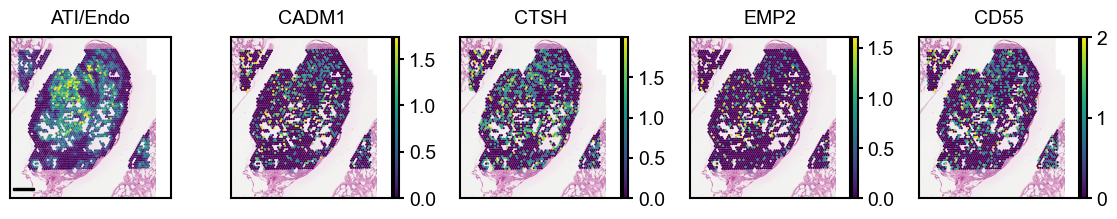

In [ ]:
fig, ax = plt.subplots(1,5, figsize=(2.3*5, 2.3))
# Add scalebar
scale_bar_length = adata_vis.uns['spatial']["08_38774_B2"]['scalefactors']['tissue_hires_scalef'] # Length of the scale bar in whatever units 
                # with ax1.transAxes, this is the proportion of the total pixel width
                # ex. 10th of 14000 px, where each px is 0.5 micron
scale_bar_height = 0.01 # Height of the scale bar (adjust as needed)

# Create a rectangle for the scale bar on top of the plot
scale_bar = Rectangle(
(0.02,0.05),  # Bottom-left corner of the rectangle (relative coordinates)
width=scale_bar_length,  # Length of the scale bar
height=scale_bar_height,  # Height of the scale bar
transform=ax[0].transAxes,  # Transform relative to the axis
color='black',  # Color of the scale bar
linewidth=1  # Thickness of the scale bar
)
sc.pl.spatial(
    adata_vis[adata_vis.obs['library_id']=="08_38774_B2"],   
    library_id = "08_38774_B2",
    color="ATI/Endo",
    size=1.5,
    vmax = 'p99',
    ax=ax[0],
    show=False,
    colorbar_loc = None
    #title=gene
)
ax[0].set_title("ATI/Endo", fontsize = 14, pad =10)
ax[0].set_xlabel("")
ax[0].set_ylabel("")
ax[0].set_xlim(0,2000)
ax[0].set_ylim(2000,0)
for i, gene in enumerate(['CADM1','CTSH',"EMP2","CD55"]):
    sc.pl.spatial(
        adata_vis[adata_vis.obs['library_id']=="08_38774_B2"],      
        library_id = "08_38774_B2",
        color=gene,
        size=1.5,
        vmax = 'p99',
        ax=ax[i+1],
        show=False,
        #colorbar_loc = None
        #title=gene
    )
    ax[i+1].set_title(gene, fontsize = 14, pad =10)
    ax[i+1].set_xlabel("")
    ax[i+1].set_ylabel("")
    ax[i+1].set_xlim(0,2000)
    ax[i+1].set_ylim(2000,0)
ax[0].add_patch(scale_bar)

plt.tight_layout()
plt.savefig(os.path.join(save_dir,"CHP_08_38774_B2_ATI_Endo_four_unique_svgs.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()

In [369]:
from collections import defaultdict
import pandas as pd
from itertools import combinations



# Step 1: Aggregate top N genes per niche per condition
from collections import defaultdict, Counter
import pandas as pd
import math

top_n = 100

#spearman_threshold = 0.4  # optional: use if you want to filter by correlation

# Count gene frequency across libraries
# Create a two-levle dictionary: the innermost values are Counters
gene_counts_by_condition = defaultdict(lambda: defaultdict(Counter))
# This one is not really necessary since I already know how many samples there are for each condition
library_counts_by_condition = defaultdict(lambda: defaultdict(int))

# Step 1: Collect gene frequencies
for condition, lib_dict in niche_gene_overlap.items(): # ex. "IPF", "18_57617_A1"
    for library_id, niche_dict in lib_dict.items(): # ex. "18_57617_A1", "B"
        for niche, df in niche_dict.items(): # ex. "B", dataframe
            top_genes = (
                # df[df["spearman_corr"] >= spearman_threshold]
                # #.sort_values("spearman_corr", ascending=False)
                # #.head(top_n)["gene"]
                df.sort_values("spearman_corr", ascending=False).head(top_n)["gene"]
                #df[df["fdr_bh"] < 0.05].sort_values("spearman_corr", ascending=False)["gene"]

            )
            gene_counts_by_condition[condition][niche].update(top_genes) # Add "top_genes" to Counter(). Automatically calculates geneX: #
            # .update() adds multiple items
            library_counts_by_condition[condition][niche] += 1


# Create a two-levle dictionary: the innermost values are sets
top_genes_by_condition = defaultdict(lambda: defaultdict(set))

# Step 2: Keep only genes appearing in >= 60% of libraries
for condition in gene_counts_by_condition: # returns IPF, NSIP, CHP
    for niche in gene_counts_by_condition[condition]:
        gene_counter = gene_counts_by_condition[condition][niche]
        lib_count = library_counts_by_condition[condition][niche]
        threshold = math.ceil(0.6  * lib_count) # Calculate 60% of library # per condition

        for gene, count in gene_counter.items(): # returns (geneX, #), (geneY, #), (geneZ, #)...
            if count >= threshold:
                top_genes_by_condition[condition][niche].add(gene) # to add one gene at a time


# Step 2: For each niche, compare gene sets across IPF, CHP, NSIP
conditions = ["IPF", "CHP", "NSIP"]

for niche in sorted(set().union(*[d.keys() for d in top_genes_by_condition.values()])):
    print(f"\n--- Niche: {niche} ---")
    
    gene_sets = {cond: top_genes_by_condition[cond].get(niche, set()) for cond in conditions}
    
    # Three-way overlap
    overlap_all = gene_sets["IPF"] & gene_sets["CHP"] & gene_sets["NSIP"]
    print(f"Genes shared by all conditions ({len(overlap_all)}): {sorted(overlap_all)}")

    # Pairwise Jaccard indices
    for cond1, cond2 in combinations(conditions, 2):
        set1 = gene_sets[cond1]
        set2 = gene_sets[cond2]
        if set1 or set2:
            jaccard = len(set1 & set2) / len(set1 | set2)
            print(f"Jaccard({cond1}, {cond2}): {jaccard:.2f}")
        else:
            print(f"Jaccard({cond1}, {cond2}): N/A (one or both sets empty)")

    # Unique genes per condition
    for cond in conditions:
        others = set().union(*(gene_sets[c] for c in conditions if c != cond))
        unique = gene_sets[cond] - others
        print(f"Unique to {cond} ({len(unique)}): {sorted(unique)}")



--- Niche: ATI/Endo ---
Genes shared by all conditions (26): ['AGER', 'ANXA3', 'AQP4', 'CADM1', 'CAV1', 'CD55', 'CEACAM6', 'CLIC5', 'DHCR24', 'EMP2', 'FASN', 'FCN3', 'GPRC5A', 'KRT7', 'LMO7', 'LPCAT1', 'MUC1', 'MYH14', 'NAPSA', 'NDNF', 'NHERF2', 'SCEL', 'SFTPA1', 'SFTPC', 'SFTPD', 'SLC34A2']
Jaccard(IPF, CHP): 0.51
Jaccard(IPF, NSIP): 0.49
Jaccard(CHP, NSIP): 0.49
Unique to IPF (18): ['ANXA2', 'CD74', 'CD9', 'CTSE', 'CXCL17', 'DMBT1', 'KRT8', 'LMO3', 'LTA4H', 'NKX2-1', 'PRR15L', 'SDC4', 'SELENBP1', 'SFTA3', 'SLC22A31', 'TMPRSS2', 'TMSB4X', 'VIPR1']
Unique to CHP (9): ['CAV2', 'PEBP4', 'PIGR', 'PRX', 'RNASE1', 'RTKN2', 'SLC39A8', 'SPTBN1', 'VEGFA']
Unique to NSIP (2): ['EPS8L2', 'FXYD3']

--- Niche: ATII ---
Genes shared by all conditions (53): ['ABCA3', 'AHCYL2', 'ALOX15B', 'ALPL', 'AQP3', 'C16orf89', 'C4BPA', 'CACNA2D2', 'CADM1', 'CPM', 'CTSH', 'CXCL17', 'CYB5A', 'DHCR24', 'DMBT1', 'DRAM1', 'FASN', 'FOLR1', 'IRX3', 'KCNJ15', 'LAMP3', 'LMO3', 'LPCAT1', 'LRRK2', 'MBIP', 'MLPH', 'MUC1',

In [392]:
top_genes_by_condition

defaultdict(<function __main__.<lambda>()>,
            {'IPF': defaultdict(set,
                         {'B': {'AKNA',
                           'ARHGAP45',
                           'BLK',
                           'CCL19',
                           'CD37',
                           'CD79A',
                           'CORO1A',
                           'CXCR4',
                           'IGHG1',
                           'IGKC',
                           'IKZF1',
                           'JAK3',
                           'LSP1',
                           'LTB',
                           'MAP4K1',
                           'MS4A1',
                           'NIBAN3',
                           'RAC2',
                           'SEPTIN1',
                           'TNFRSF13C',
                           'TRAC',
                           'TRAF3IP3',
                           'TRBC1',
                           'TRBC2'},
                          'ATI/Endo': {'AGER'

In [370]:
# import json
# for condition, nested_dict in top_genes_by_condition.items():
#     # Convert inner sets to lists
#     clean_dict = {k: list(v) for k, v in nested_dict.items()}
    
#     filename =  f"{save_dir}/{condition}_genes.json"
#     with open(filename, "w") as f:
#         json.dump(clean_dict, f, indent=2)
#     print(f"Saved {filename}")

In [371]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create a DataFrame to store Jaccard indices
jaccard_df = pd.DataFrame()

# Prepare list of all niches
all_niches = sorted(adata_vis.obs['factor_assigned'].unique())

# List of all pairwise comparisons
pairwise_comparisons = list(combinations(conditions, 2))

# Collect Jaccard values
for niche in all_niches:
    # A dictionary: {cond: {gene1, gene2, ...geneX}
    # .get() checks for niche without modifying the dictionary
    # If niche is missing, returns an empty set
    gene_sets = {cond: top_genes_by_condition[cond].get(niche, set()) for cond in conditions}
    
    for cond1, cond2 in pairwise_comparisons:
        set1 = gene_sets[cond1] # set of genes for cond1
        set2 = gene_sets[cond2] 
        comparison_label = f"{cond1} vs {cond2}"
        if set1 or set2:
            jaccard = len(set1 & set2) / len(set1 | set2)
        else:
            jaccard = float('nan')  # or 0.0 if you prefer
        
        jaccard_df.loc[comparison_label, niche] = jaccard


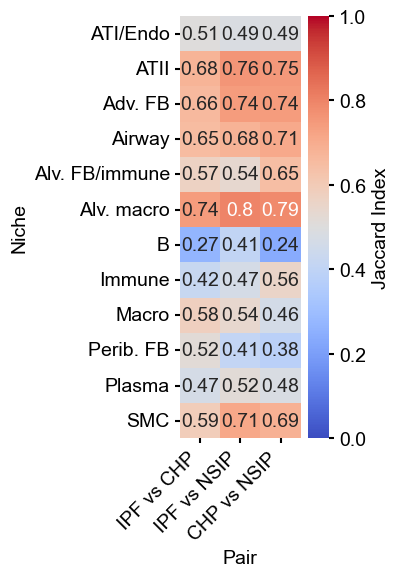

In [372]:
plt.figure(figsize=(4,6))
sns.heatmap(jaccard_df.T, annot=True, cmap="coolwarm", vmin=0, vmax=1, cbar_kws={'label': 'Jaccard Index'})
plt.title("")
plt.xlabel("Pair")
plt.ylabel("Niche")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(save_dir,"hm_niche_jaccard_top100genes_shared60p.pdf"), bbox_inches = "tight", transparent = True)
plt.show()


In [377]:
niche_gene_overlap["IPF"].keys()

dict_keys(['18_57617_A1', '20_33940_B2', '20_24241_A2', '20_28197_A1', '20_41501_C1', '20_41615_B1', '21_06301_B2', '21_24095_A3', '21_55747_C3', '22_16220_B1'])

In [378]:
niche_gene_overlap["CHP"].keys()

dict_keys(['21_57231_A3', '22_18440_A2', '23_15209_A3', '23_50343_B2', '23_41922_B2', '24_27523_C5', '11_13888_A1', '17_25789_B1', '08_38774_B2', '16_39724_B1'])

In [379]:
custom_genes = ['AGER']
target_niche = "ATI/Endo"

# DataFrame to collect results
records = []

for condition, lib_dict in niche_gene_overlap.items():
    for library_id, niche_dict in lib_dict.items():
        if target_niche not in niche_dict:
            continue

        df = niche_dict[target_niche].sort_values("spearman_corr", ascending=False).reset_index(drop=True)

        for gene in custom_genes:
            match = df[df["gene"] == gene]
            if not match.empty:
                rank = match.index[0] + 1  # 1-based index
            else:
                rank = None  # Not found

            records.append({
                "condition": condition,
                "library_id": library_id,
                "niche": target_niche,
                "gene": gene,
                "rank": rank
            })

# Create a DataFrame of results
gene_rank_df = pd.DataFrame(records)

# Preview
print(gene_rank_df)


   condition   library_id     niche  gene  rank
0        IPF  18_57617_A1  ATI/Endo  AGER     1
1        IPF  20_33940_B2  ATI/Endo  AGER     4
2        IPF  20_24241_A2  ATI/Endo  AGER     3
3        IPF  20_28197_A1  ATI/Endo  AGER    17
4        IPF  20_41501_C1  ATI/Endo  AGER     2
5        IPF  20_41615_B1  ATI/Endo  AGER     9
6        IPF  21_06301_B2  ATI/Endo  AGER    38
7        IPF  21_24095_A3  ATI/Endo  AGER     6
8        IPF  21_55747_C3  ATI/Endo  AGER     1
9        IPF  22_16220_B1  ATI/Endo  AGER     7
10      NSIP  19_35057_C3  ATI/Endo  AGER     4
11      NSIP  20_17688_B2  ATI/Endo  AGER     1
12      NSIP  20_22642_A1  ATI/Endo  AGER    21
13      NSIP  20_33362_C4  ATI/Endo  AGER     9
14      NSIP  20_26330_B3  ATI/Endo  AGER     4
15      NSIP  21_24837_A1  ATI/Endo  AGER     3
16      NSIP  06_30914_A1  ATI/Endo  AGER     5
17      NSIP  19_18542_A4  ATI/Endo  AGER     4
18       CHP  21_57231_A3  ATI/Endo  AGER     3
19       CHP  22_18440_A2  ATI/Endo  AGE

In [380]:
niche_gene_overlap["CHP"]['21_57231_A3']['ATI/Endo'].reset_index()

,index,gene,spearman_corr,pval,fdr_bh
0,12,SFTPB,0.674780,0.000000e+00,0.000000e+00
1,3,SFTPC,0.573720,3.184980e-218,8.828765e-215
2,94,AGER,0.538670,1.225652e-187,2.265005e-184
3,15,SFTPA1,0.535688,3.358791e-185,4.655284e-182
4,68,SFTPD,0.514211,2.426272e-168,2.690250e-165
...,...,...,...,...,...
5539,160,VCAN,-0.255745,1.602152e-38,1.708141e-36
5540,202,TNFAIP3,-0.256405,1.018671e-38,1.107355e-36
5541,53,CCL19,-0.277793,2.077162e-45,2.559064e-43
5542,50,S100A8,-0.303066,4.039369e-54,6.786139e-52


In [120]:
import gseapy as gp


ModuleNotFoundError: No module named 'gseapy'

In [382]:
gp.get_library_name(organism='Human')

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'COMPARTMENTS_Curated_2025',
 'COMPARTMENTS_Experimental_2025',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popular_Genes',
 'DepMap_CRISPR_GeneDependency_CellLines_2023',
 'DepMap_WG_CRISPR_Scre

In [383]:
top_genes_by_condition

defaultdict(<function __main__.<lambda>()>,
            {'IPF': defaultdict(set,
                         {'B': {'AKNA',
                           'ARHGAP45',
                           'BLK',
                           'CCL19',
                           'CD37',
                           'CD79A',
                           'CORO1A',
                           'CXCR4',
                           'IGHG1',
                           'IGKC',
                           'IKZF1',
                           'JAK3',
                           'LSP1',
                           'LTB',
                           'MAP4K1',
                           'MS4A1',
                           'NIBAN3',
                           'RAC2',
                           'SEPTIN1',
                           'TNFRSF13C',
                           'TRAC',
                           'TRAF3IP3',
                           'TRBC1',
                           'TRBC2'},
                          'ATI/Endo': {'AGER'

In [384]:
list(top_genes_by_condition['IPF']["B"])[:10
                                ]

['LTB',
 'BLK',
 'TRAF3IP3',
 'IKZF1',
 'AKNA',
 'CCL19',
 'IGKC',
 'TNFRSF13C',
 'TRBC1',
 'CXCR4']

In [385]:
top_genes_by_condition["IPF"]["B"]

{'AKNA',
 'ARHGAP45',
 'BLK',
 'CCL19',
 'CD37',
 'CD79A',
 'CORO1A',
 'CXCR4',
 'IGHG1',
 'IGKC',
 'IKZF1',
 'JAK3',
 'LSP1',
 'LTB',
 'MAP4K1',
 'MS4A1',
 'NIBAN3',
 'RAC2',
 'SEPTIN1',
 'TNFRSF13C',
 'TRAC',
 'TRAF3IP3',
 'TRBC1',
 'TRBC2'}

In [386]:
import gseapy as gp
import pandas as pd
import numpy as np
import os

os.makedirs("enrichr_results", exist_ok=True)

niches = adata_vis.obs['factor_assigned'].unique()
conditions = ["IPF", "NSIP", "CHP"]

all_results = []

for niche in niches:
    for cond in conditions:
        genes = list(top_genes_by_condition[cond][niche])  # ensure list, not set
        enr = gp.enrichr(
            gene_list=genes,
            gene_sets='GO_Biological_Process_2021',
            organism='Human',
            outdir='enrichr_results',
            cutoff=1.0
        )
        df = enr.results.copy()
        df["condition"] = cond
        df["niche"] = niche
        all_results.append(df)

# Combine all results
combined = pd.concat(all_results, ignore_index=True)
combined["Adjusted P-value"] = pd.to_numeric(combined["Adjusted P-value"], errors='coerce')
combined.dropna(subset=["Adjusted P-value"], inplace=True)
combined["-log10(padj)"] = -np.log10(combined["Adjusted P-value"].replace(0, 1e-300))


In [387]:
combined

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,condition,niche,-log10(padj)
0,GO_Biological_Process_2021,lymphocyte differentiation (GO:0030098),4/84,0.000003,0.000889,0,0,49.740000,634.478607,CD79A;IKZF1;JAK3;MS4A1,IPF,B,3.051267
1,GO_Biological_Process_2021,B cell receptor signaling pathway (GO:0050853),3/34,0.000009,0.001365,0,0,91.912442,1069.250890,BLK;CD79A;MS4A1,IPF,B,2.864785
2,GO_Biological_Process_2021,regulation of T-helper 1 cell differentiation ...,2/7,0.000029,0.001975,0,0,363.109091,3795.424957,CCL19;JAK3,IPF,B,2.704475
3,GO_Biological_Process_2021,regulation of interleukin-12 production (GO:00...,3/51,0.000030,0.001975,0,0,59.309524,616.799727,LTB;CCL19;JAK3,IPF,B,2.704475
4,GO_Biological_Process_2021,regulation of lymphocyte apoptotic process (GO...,2/8,0.000038,0.001975,0,0,302.575758,3075.871223,BLK;JAK3,IPF,B,2.704475
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22414,GO_Biological_Process_2021,negative regulation of cellular process (GO:00...,1/566,0.816634,0.822033,0,0,0.591273,0.119771,ALOX15B,CHP,ATII,0.085111
22415,GO_Biological_Process_2021,cytokine-mediated signaling pathway (GO:0019221),1/621,0.844907,0.849090,0,0,0.537291,0.090549,MUC1,CHP,ATII,0.071046
22416,GO_Biological_Process_2021,"positive regulation of transcription, DNA-temp...",2/1183,0.871360,0.874231,0,0,0.557363,0.076749,IRX3;NKX2-1,CHP,ATII,0.058374
22417,GO_Biological_Process_2021,regulation of transcription by RNA polymerase ...,3/2206,0.965142,0.966730,0,0,0.431344,0.015304,MUC1;IRX3;NKX2-1,CHP,ATII,0.014695


In [388]:
# Remove text within parentheses (and the parentheses themselves)
combined['Term'] = combined['Term'].str.replace(r'\s*\(.*?\)', '', regex=True)
combined

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,condition,niche,-log10(padj)
0,GO_Biological_Process_2021,lymphocyte differentiation,4/84,0.000003,0.000889,0,0,49.740000,634.478607,CD79A;IKZF1;JAK3;MS4A1,IPF,B,3.051267
1,GO_Biological_Process_2021,B cell receptor signaling pathway,3/34,0.000009,0.001365,0,0,91.912442,1069.250890,BLK;CD79A;MS4A1,IPF,B,2.864785
2,GO_Biological_Process_2021,regulation of T-helper 1 cell differentiation,2/7,0.000029,0.001975,0,0,363.109091,3795.424957,CCL19;JAK3,IPF,B,2.704475
3,GO_Biological_Process_2021,regulation of interleukin-12 production,3/51,0.000030,0.001975,0,0,59.309524,616.799727,LTB;CCL19;JAK3,IPF,B,2.704475
4,GO_Biological_Process_2021,regulation of lymphocyte apoptotic process,2/8,0.000038,0.001975,0,0,302.575758,3075.871223,BLK;JAK3,IPF,B,2.704475
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22414,GO_Biological_Process_2021,negative regulation of cellular process,1/566,0.816634,0.822033,0,0,0.591273,0.119771,ALOX15B,CHP,ATII,0.085111
22415,GO_Biological_Process_2021,cytokine-mediated signaling pathway,1/621,0.844907,0.849090,0,0,0.537291,0.090549,MUC1,CHP,ATII,0.071046
22416,GO_Biological_Process_2021,"positive regulation of transcription, DNA-temp...",2/1183,0.871360,0.874231,0,0,0.557363,0.076749,IRX3;NKX2-1,CHP,ATII,0.058374
22417,GO_Biological_Process_2021,regulation of transcription by RNA polymerase II,3/2206,0.965142,0.966730,0,0,0.431344,0.015304,MUC1;IRX3;NKX2-1,CHP,ATII,0.014695


In [389]:
top_terms = []

for niche in niches:
    niche_data = combined[combined["niche"] == niche]
    top5 = (
        niche_data.groupby("Term")["Adjusted P-value"]
        .min()
        .sort_values()
        .head(2)
        .index
    )
    top_terms.extend(top5)

# Unique union of top terms across niches
unique_terms = list(pd.Series(top_terms).unique())

# Filter combined results for those terms
filtered = combined[combined["Term"].isin(unique_terms)].copy()

# Create a combined column for heatmap columns
filtered["label"] = filtered["niche"] + "_" + filtered["condition"]


In [390]:
# Pivot to term × (niche_condition)
heatmap_data = filtered.pivot_table(
    index="Term",
    columns="label",
    values="-log10(padj)",
    fill_value=0
)

import scipy.cluster.hierarchy as sch
# Optional: sort rows by average signal
#heatmap_data = heatmap_data.loc[heatmap_data.mean(axis=1).sort_values(ascending=False).index]
# Perform hierarchical clustering on columns (niche_condition)
# We are clustering columns based on their similarity
Z = sch.linkage(heatmap_data, method='complete', metric='euclidean')

# Get the order of columns based on hierarchical clustering
dendrogram = sch.dendrogram(Z, no_plot=True)
row_order = dendrogram['leaves']


desired_condition_order = ['IPF', 'NSIP', 'CHP']

# Extract unique niches
niches = sorted({label.split('_')[0] for label in heatmap_data.columns})

# Build ordered column list like macro_IPF, macro_NSIP, macro_CHP, ...
col_order = [f"{niche}_{cond}" for niche in niches for cond in desired_condition_order if f"{niche}_{cond}" in heatmap_data.columns]



# Reorder the rows of the heatmap
heatmap_data = heatmap_data.iloc[row_order,:]
# Reorder the columns of the heatmap 
heatmap_data = heatmap_data.loc[:,col_order]

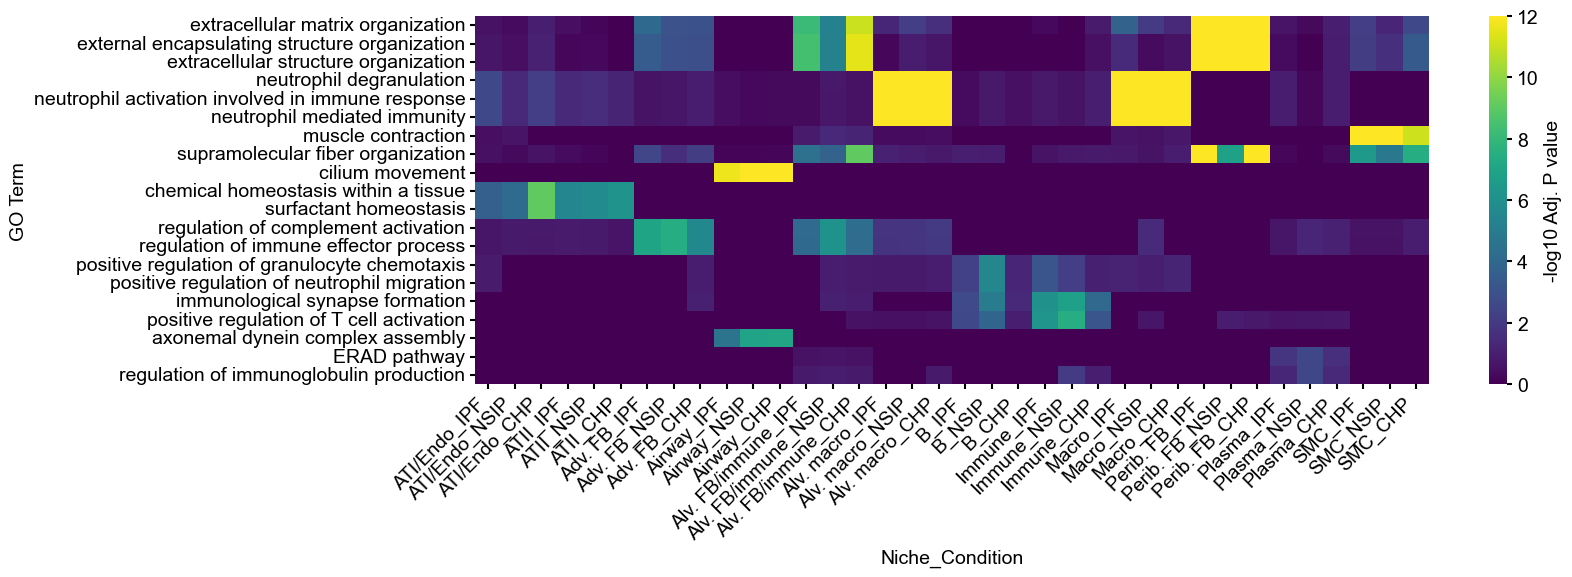

In [391]:
import seaborn as sns
import matplotlib.pyplot as plt

color_dict = dict(zip(
['ATI/Endo',
 'Perib. FB',
 'ATII',
 'Plasma',
 'Airway',
 'B',
 'Alv. macro',
 'Alv. FB/immune',
 'Adv. FB',
 'Macro',
 'Immune',
 'SMC'],
 ['#ff7f00', '#33a02c', '#fdbf6f', '#1f78b4', '#fb9a99', '#cab2d6', '#6a3d9a', '#ffff99', '#b15928', '#b2df8a', '#a6cee3', '#e31a1c']

))



plt.figure(figsize=(17, len(heatmap_data) * 0.3))
sns.heatmap(heatmap_data, cmap="viridis", annot=False, fmt=".1f", cbar_kws={'label': '-log10 Adj. P value'}, vmax = 12)
plt.title("")
plt.xlabel("Niche_Condition")
plt.ylabel("GO Term")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(save_dir,"hm_gsea_top100genes_shared60p.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()


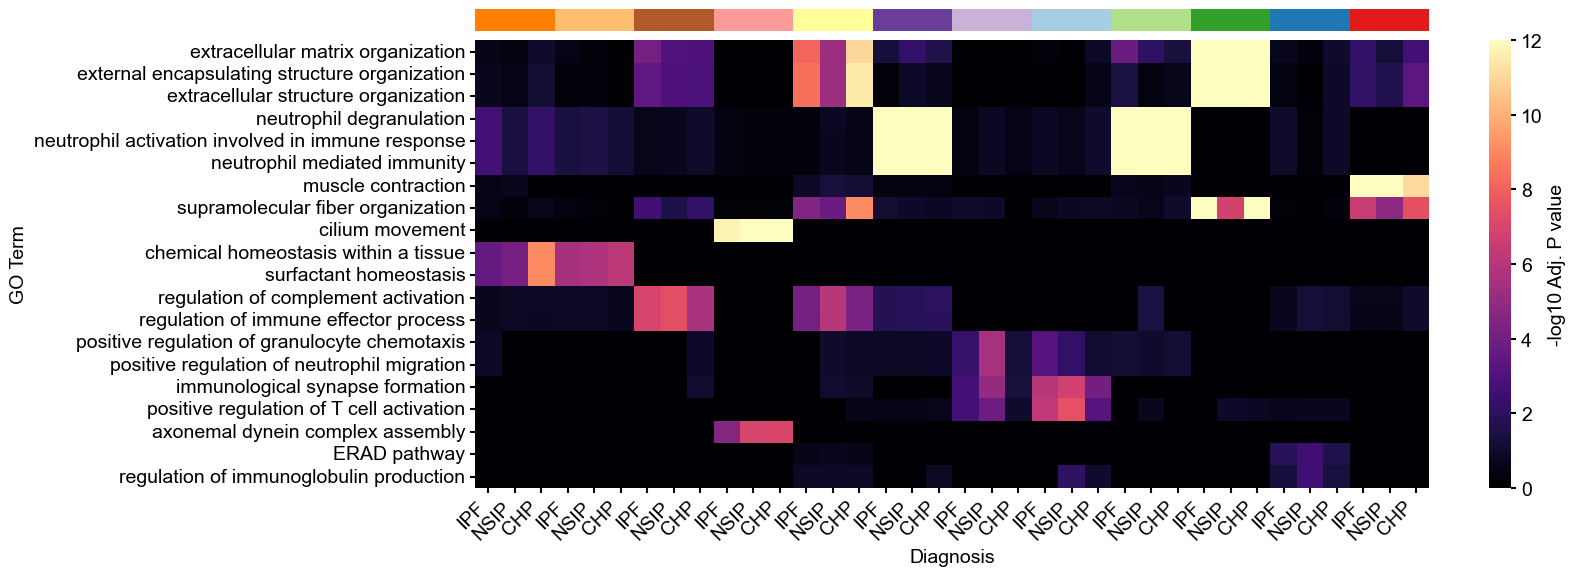

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Assume heatmap_data is your data frame
fig, ax = plt.subplots(figsize=(17, len(heatmap_data)*0.3))

# Plot the heatmap
sns.heatmap(
    heatmap_data, 
    cmap="magma", 
    annot=False, 
    fmt=".1f", 
    cbar_kws={'label': '-log10 Adj. P value'}, 
    vmax=12, 
    ax=ax
)

# Extract prefixes and map to colors
col_prefixes = [col.split('_')[0] for col in heatmap_data.columns]
colors = [color_dict.get(prefix, '#ffffff') for prefix in col_prefixes]

# Add a colored rectangle strip BELOW the x-axis
rect_y = 1.02  # a bit below the axis
rect_height = 0.05  # thin bar height

for i, color in enumerate(colors):
    rect = patches.Rectangle(
        (i, rect_y),  # x = column index, y = below x-axis
        width=1,
        height=rect_height,
        facecolor=color,
        edgecolor='none',
        transform=ax.get_xaxis_transform(),  # x in data coords, y in axis coords
        clip_on=False
    )
    ax.add_patch(rect)

# for i in range(1, len(col_prefixes),3):
#     prefix = col_prefixes[i]
#     ax.text(
#         i + 0.5,         # center of the column
#         1.4,  # vertically center in the strip
#         prefix,
#         ha='center', va='center',
#         fontsize=12,
#         rotation=30,     # vertical text if horizontal space is tight
#         transform=ax.get_xaxis_transform(),  # keep in axis space
#         clip_on=False
#     )
# Style the heatmap
#ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_xlabel("Diagnosis")
ax.set_ylabel("GO Term")


new_labels = [col.split('_')[1] for col in heatmap_data.columns]
ax.set_xticklabels(new_labels, rotation =45, ha= 'right')

plt.tight_layout()
plt.savefig(os.path.join(save_dir,"hm_gsea_top100genes_shared60p_col_bar.pdf"), bbox_inches = 'tight', transparent = True)
plt.show()


In [ ]:
colors

UsageError: %colors: you must specify a color scheme. See '%colors?'


In [3]:
top_genes_by_condition

NameError: name 'top_genes_by_condition' is not defined